# Commento e riproduzione dei risultati ottenuti nel paper di riferimento:

### "Impacts of competition and phenotypic plasticity on the viability of adaptive therapy", di B. Vibishan, Paras Jain, Vedant Sharma, Kishore Hari, Claus Kadelka, Jason T. George, Mohit Kumar Jolly

### 1. Il Sistema Base

Il modello descrive la dinamica di due popolazioni cellulari, sensibili ($s$) e resistenti ($r$), attraverso il seguente sistema di equazioni differenziali ordinarie basato sulla competizione di Lotka-Volterra:

$$\frac{ds}{dt} = r_s s \left( 1 - \frac{s + \alpha_{rs}r}{K} \right) - t_s s + t_r r$$

$$\frac{dr}{dt} = r_r r \left( 1 - \frac{r + \alpha_{sr}s}{K} \right) + t_s s - t_r r$$

Dove i parametri (tutti non negativi) rappresentano:
* $r_s, r_r$: Tassi di crescita specifici delle due popolazioni.
* $K$: Capacità portante del sistema (fissata a 10.000 dagli autori).
* $\alpha_{rs}$: Effetto inibitorio delle cellule resistenti su quelle sensibili.
* $\alpha_{sr}$: Effetto inibitorio delle cellule sensibili su quelle resistenti.
* $t_s$: Tasso di transizione fenotipica dallo stato sensibile a quello resistente.
* $t_r$: Tasso di transizione fenotipica dallo stato resistente a quello sensibile.

# Primo risultato

Heatmap per visualizzare come al variare dei tassi di competizione e transizione varia la condizione della massa tumorale. Ci aspettiamo che modificando la competizione e la transizione vedremo "vincere" le cellule sensibili o resistenti, in base a come variano i tassi.

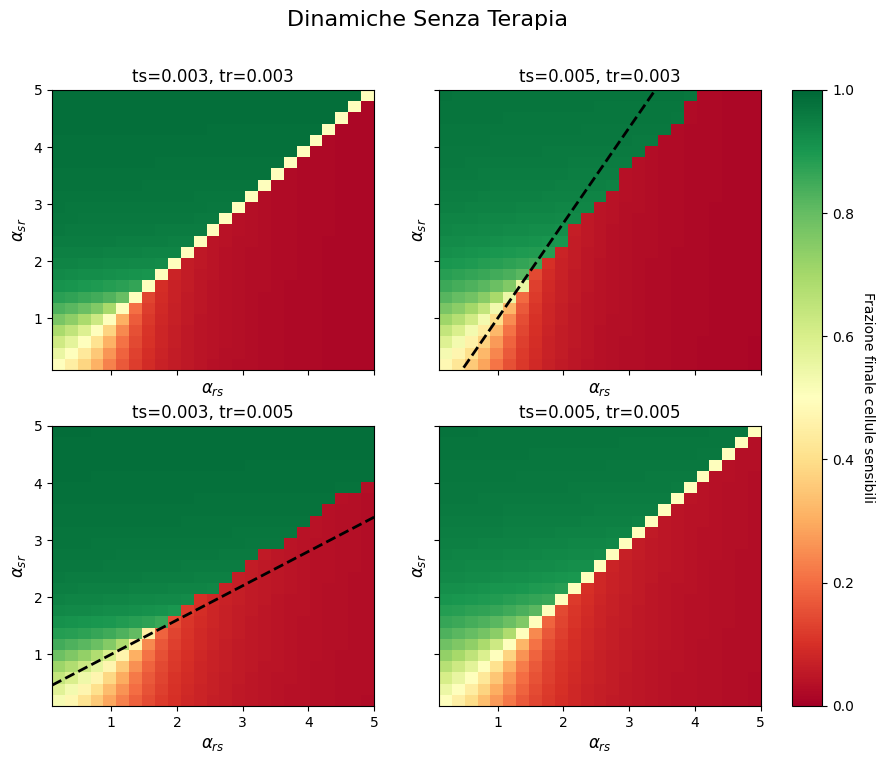

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import seaborn as sns

#Modello
def tumor_model(t, y, rs, rr, alpha_rs, alpha_sr, ts, tr, K=10000):
    s, r = max(0, y[0]), max(0, y[1]) # Evitiamo popolazioni negative
    ds_dt = rs * s * (1 - (s + alpha_rs * r) / K) - ts * s + tr * r
    dr_dt = rr * r * (1 - (r + alpha_sr * s) / K) + ts * s - tr * r
    return [ds_dt, dr_dt]

#Parametri fissi
K = 10000
rs = 0.05
rr = 0.05
y0 = [100, 100]
t_span = (0, 5000)

#Tassi di transizione
transitions = [(0.003, 0.003), (0.005, 0.003), 
               (0.003, 0.005), (0.005, 0.005)]

alpha_grid = np.linspace(0.1, 5.0, 25)
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (ts, tr) in enumerate(transitions):
    results_matrix = np.zeros((len(alpha_grid), len(alpha_grid)))
    
    for i, a_sr in enumerate(alpha_grid):
        for j, a_rs in enumerate(alpha_grid):
            # Risolviamo l'ODE
            sol = solve_ivp(tumor_model, t_span, y0, 
                            args=(rs, rr, a_rs, a_sr, ts, tr), 
                            method='RK45', t_eval=[5000])
            
            s_final, r_final = sol.y[0][-1], sol.y[1][-1]

            #Condizione sulla diagonale
            if ts == tr and i == j:
                fraction_s = 0.5
            else:
                fraction_s = s_final / (s_final + r_final) if (s_final + r_final) > 0 else 0
            
            results_matrix[len(alpha_grid) - 1 - i, j] = fraction_s
            
    #Heatmap
    im = axes[idx].imshow(results_matrix, cmap='RdYlGn', vmin=0, vmax=1, 
                          extent=[0.1, 5.0, 0.1, 5.0], aspect='auto')
    
    axes[idx].set_title(f"ts={ts}, tr={tr}")
    
    #Linea tratteggiata
    if ts != tr:
        a_rs_line = np.linspace(0.1, 5.0, 100)
        a_sr_line = (ts / tr) * (a_rs_line - 1) + 1
        axes[idx].plot(a_rs_line, a_sr_line, 'k--', linewidth=2)
    
    axes[idx].set_xlim([0.1, 5.0])
    axes[idx].set_ylim([0.1, 5.0])

for ax in axes:
    ax.set_xlabel(r'$\alpha_{rs}$', fontsize=12)
    ax.set_ylabel(r'$\alpha_{sr}$', fontsize=12)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('Frazione finale cellule sensibili', rotation=270, labelpad=15)
plt.suptitle("Dinamiche Senza Terapia", fontsize=16)
plt.savefig('figura1A.png', dpi=300, bbox_inches='tight')
plt.show()

## Commenti:
 
La <font color= 'green' >zona verde</font> rappresenta lo stato **Favorevole**, ovvero dove le cellule sensibili sono maggiori di quelle resistenti, mentre, al contrario la <font color= 'red' >zona rossa </font> rappresenta lo stato **Sfavorevole**.

La linea tratteggiata nera rappresenta il confine matematico tra i due stati, ovvero lo stato: $$ \frac{t_s}{t_r} = \frac{\alpha_{sr} - 1}{\alpha_{rs} - 1} $$ Essa si trova solo nei pannelli dove ts è diverso da tr. Invece, quando ts = tr la diagonale separa perfettamente le due zone e rappresenta uno stato di equilibrio perfetto dove la competizione delle cellule resistenti verso quelle sensibili e viceversa sono identiche: in questo caso le popolazioni di cellule sensibili e resistenti si dividono esattamente in 50/50 della popolazione totale.

# Secondo risultato

Ora passiamo all'analisi statistica, dove possiamo osservare come varia la popolazione tumorale in simulazioni di più scenari. Useremo Monte-Carlo per simulare 10000 scenari e vedere come si distribuiscono. 

Uso pandas per estrarre il data frame, composto da valori randomici dei parametri generati rispettando i limiti imposti dagli autori del paper. 
Plotto i pannelli B, D insieme poiché sono analisi differenti dello stesso dataset.

C:\Users\HP\AppData\Local\Temp\ipykernel_5876\482067840.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Total_Population', data=df,


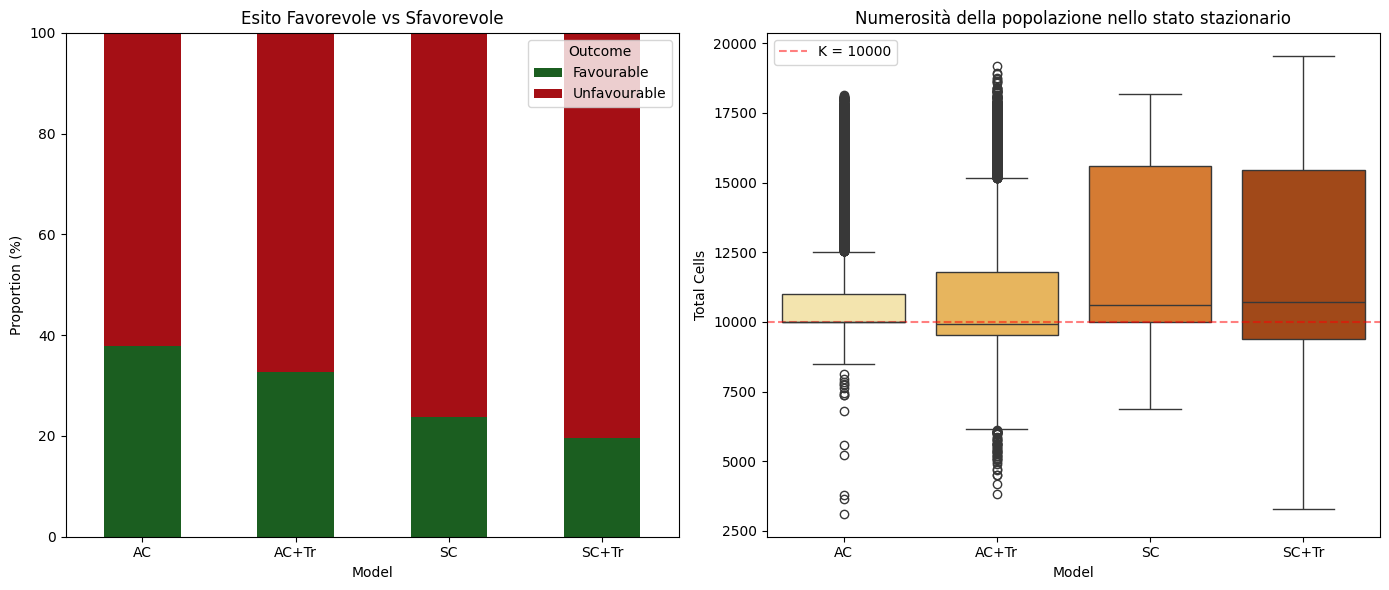

In [2]:
import pandas as pd

#Estrazione valori randomici
def log_uniform(low, high, size):
    return np.exp(np.random.uniform(np.log(low), np.log(high), size))

N_SAMPLES = 10000

#Range dei valori
rs_vals = log_uniform(0.00247, 0.05, N_SAMPLES)
rr_vals = log_uniform(0.00247, 0.05, N_SAMPLES)
ts_vals = log_uniform(0.000125, 0.0015, N_SAMPLES)
tr_vals = log_uniform(0.000125, 0.0015, N_SAMPLES)
ars_vals = log_uniform(0.1, 7.4, N_SAMPLES)
asr_vals = log_uniform(0.1, 7.4, N_SAMPLES)

data_list = []

for idx in range(N_SAMPLES):
    rs, rr = rs_vals[idx], rr_vals[idx]
    
    #4 scenari
    scenarios = {
        'AC':    {'a_rs': ars_vals[idx], 'a_sr': asr_vals[idx], 'ts': 0, 'tr': 0},
        'AC+Tr': {'a_rs': ars_vals[idx], 'a_sr': asr_vals[idx], 'ts': ts_vals[idx], 'tr': tr_vals[idx]},
        'SC':    {'a_rs': ars_vals[idx], 'a_sr': ars_vals[idx], 'ts': 0, 'tr': 0},
        'SC+Tr': {'a_rs': ars_vals[idx], 'a_sr': ars_vals[idx], 'ts': ts_vals[idx], 'tr': tr_vals[idx]}
    }
    
    for model_name, p in scenarios.items():
        sol = solve_ivp(tumor_model, (0, 5000), [100, 100], 
                        args=(rs, rr, p['a_rs'], p['a_sr'], p['ts'], p['tr']), 
                        method='RK45', t_eval=[5000])
        
        s_end, r_end = sol.y[0][-1], sol.y[1][-1]
        tot_end = s_end + r_end
        frac_s = s_end / tot_end if tot_end > 0 else 0
        
        # Classificazione Favorevole o Sfavorevole
        outcome = 'Favourable' if frac_s > 0.85 else 'Unfavourable'
        
        data_list.append({
            'Model': model_name,
            'Total_Population': tot_end,
            'Outcome': outcome
        })

df = pd.DataFrame(data_list)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
crosstab = pd.crosstab(df['Model'], df['Outcome'], normalize='index') * 100
crosstab = crosstab.reindex(['AC', 'AC+Tr', 'SC', 'SC+Tr'])
crosstab.plot(kind='bar', stacked=True, color=['#1b5e20', '#a50f15'], ax=ax1)
ax1.set_ylabel('Proportion (%)')
ax1.set_title('Esito Favorevole vs Sfavorevole')
ax1.set_ylim([0, 100])
ax1.tick_params(axis='x', rotation=0)

sns.boxplot(x='Model', y='Total_Population', data=df, 
            order=['AC', 'AC+Tr', 'SC', 'SC+Tr'], 
            ax=ax2, palette="YlOrBr")
ax2.axhline(10000, color='red', linestyle='--', alpha=0.5, label='K = 10000')
ax2.set_title('Numerosità della popolazione nello stato stazionario')
ax2.set_ylabel('Total Cells')
ax2.legend()

plt.tight_layout()
plt.savefig('figura1B.png', dpi=300, bbox_inches='tight')
plt.show()

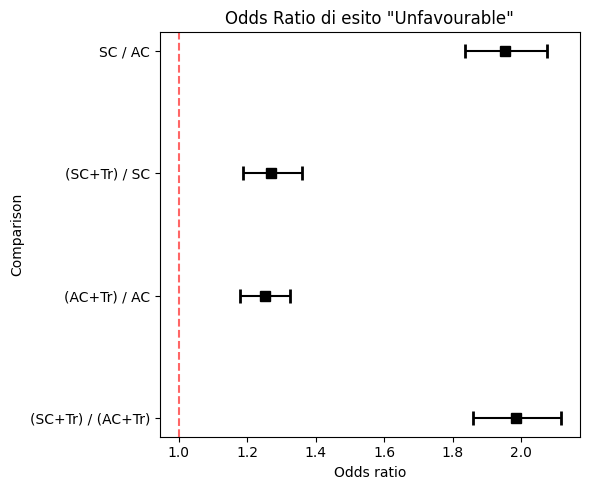

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def calc_odds_ratio(df, model_num, model_den):
    
    counts_num = df[df['Model'] == model_num]['Outcome'].value_counts()
    unfav_num = counts_num.get('Unfavourable', 0)
    fav_num = counts_num.get('Favourable', 0)
    
    counts_den = df[df['Model'] == model_den]['Outcome'].value_counts()
    unfav_den = counts_den.get('Unfavourable', 0)
    fav_den = counts_den.get('Favourable', 0)
    
    # Correzione nel caso in cui un conteggio sia zero
    if unfav_num == 0 or fav_num == 0 or unfav_den == 0 or fav_den == 0:
        unfav_num += 0.5; fav_num += 0.5; unfav_den += 0.5; fav_den += 0.5
        
    odds_num = unfav_num / fav_num
    odds_den = unfav_den / fav_den

    OR = odds_num / odds_den
    
    # Calcolo dell'Errore Standard e dell'Intervallo di Confidenza
    se_log_or = np.sqrt(1/unfav_num + 1/fav_num + 1/unfav_den + 1/fav_den)
    ci_lower = np.exp(np.log(OR) - 1.96 * se_log_or)
    ci_upper = np.exp(np.log(OR) + 1.96 * se_log_or)
    
    return OR, ci_lower, ci_upper

#4 comparazioni
comparisons = [
    ('SC', 'AC', 'SC / AC'),
    ('SC+Tr', 'SC', '(SC+Tr) / SC'),
    ('AC+Tr', 'AC', '(AC+Tr) / AC'),
    ('SC+Tr', 'AC+Tr', '(SC+Tr) / (AC+Tr)')
]

or_values = []
errors_lower = []
errors_upper = []
labels = []

for num, den, label in comparisons:
    OR, lower, upper = calc_odds_ratio(df, num, den)
    or_values.append(OR)
    errors_lower.append(OR - lower)
    errors_upper.append(upper - OR)
    labels.append(label)

fig, ax = plt.subplots(figsize=(6, 5))

y_pos = np.arange(len(labels))

ax.errorbar(or_values, y_pos, xerr=[errors_lower, errors_upper], fmt='s', 
            color='black', ecolor='black', capsize=5, capthick=2, markersize=7)
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.6)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('Odds ratio')
ax.set_ylabel('Comparison')
ax.set_title('Odds Ratio di esito "Unfavourable"')

ax.invert_yaxis() 

plt.tight_layout()
plt.savefig('figura1C.png', dpi=300, bbox_inches='tight')
plt.show()

## Commenti:
Tutte le simulazioni sono state fatte su scenari con condizioni iniziali randomiche generate in un range fissato, quindi restartando il codice si vedranno risultati leggermente diversi. Le linee nere indicano gli intervalli di confidenza dei risultati, minore è l'errore standard minore sarà la larghezza dell'intervallo. Quindi è necessario svolgere tante simulazioni per ottenere risultati veritieri.

### Grafico 1B: 
Questo grafico rappresenta la percentuale che si presenti uno scenario favorevole rispetto alla probabilità che se ne verifichi uno sfavorevole. Si nota in modo chiaro che lo scenario che ha più probabilità di avere un esito favorevole è quello della *competitività asimettrica senza transizioni (AC)*.

### Grafico 1C:
Qui si mettono a confronto a due a due degli scenari diversi dove si rapportano la rispettiva probabilità di cadere in uno scenario sfavorevole. Ad esempio si vede chiaramente che quando la competitività è simmetrica è molto più probabile che l'esito delle simulazioni sia sfavorevole rispetto alla competitività asimettrica. Inoltre il "baffo" dei risultati raffigura la deviazione standard (SD) e, come ci si poteva aspettare, all'aumentare dei samples si stringe sempre di più. Invece il quadratino centrale rappresenta la mediana dei risultati.

### Grafico 1D:
La struttura di questo grafico è molto simile a quella dell'1C. Tuttavia, qui si prende in esame il numero totale di cellule alla fine della simulazione, sia sensibili che resistenti. Ad esempio, si può notare che rispecchia fedelmente i risultati ottenuti nel grafico 1B, poiché per gli scenari più inclini ad essere sfavorevoli (SC, SC+Tr) si vede che la popolazione del tumore cresce al di sopra di 10000 unità. Facendo più simulazioni il risultato resta simile.


# Fase 2: Modellizzazione della Terapia Continua (CT)

In questa fase, introduciamo l'intervento farmacologico nel sistema. Nella **Terapia Continua**, il farmaco viene somministrato ininterrottamente. Il modello distingue tra due possibili effetti del farmaco: **citostatico** (che blocca la proliferazione) e **citotossico** (che uccide le cellule attivamente).

## Modifiche al Modello Matematico
L'effetto della terapia viene modellato modificando l'equazione delle cellule <span style="color: #1b5e20; font-weight: bold;">sensibili</span> in due punti: aggiungendo il moltiplicatore $\gamma$ alla crescita e il termine di mortalità lineare $-d_{th} s$. Le cellule <span style="color: #b2182b; font-weight: bold;">resistenti</span>, per definizione, non vengono colpite direttamente dal trattamento.

Il sistema di equazioni differenziali (System 2) diventa:

$$\frac{ds}{dt} = \gamma r_s s \left( 1 - \frac{s + \alpha_{rs}r}{K} \right) - t_s s + t_r r - d_{th} s$$

$$\frac{dr}{dt} = r_r r \left( 1 - \frac{r + \alpha_{sr}s}{K} \right) + t_s s - t_r r$$

## Parametri della Terapia
* $\gamma$: Misura l'efficacia della **terapia citostatica** ($\gamma \in (0, 1]$). Agisce come un freno: un valore più basso indica un farmaco più potente nel fermare la divisione cellulare delle sensibili. Se $\gamma = 1$, non c'è effetto citostatico.
* $d_{th}$: Rappresenta il tasso di mortalità indotto dalla **terapia citotossica** ($d_{th} \ge 0$). Se sufficientemente alto, garantisce una riduzione attiva della massa tumorale iniziale.
* **Obiettivo:** Osservare il fenomeno del *competitive release*: eliminando o inibendo rapidamente le cellule sensibili, la pressione ecologica e competitiva sulle cellule resistenti scompare, portando inevitabilmente a una recidiva guidata dalla popolazione resistente.

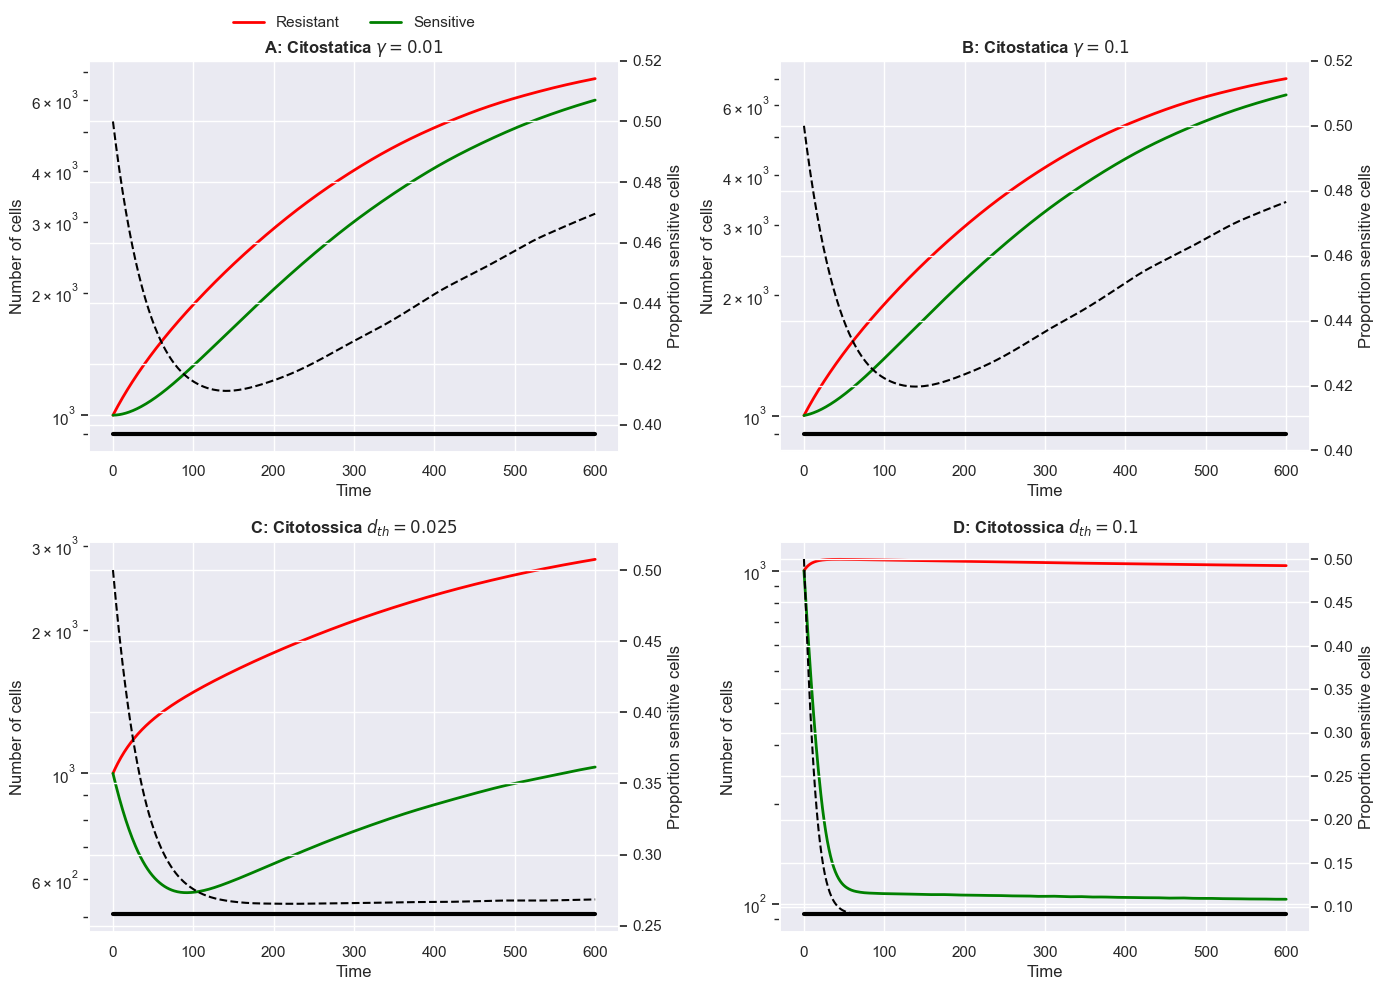

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

#Modello con terapia continua
def tumor_model_therapy(t, y, rs, rr, alpha_rs, alpha_sr, ts, tr, gamma, d_th, K=10000):
    s, r = max(0, y[0]), max(0, y[1])
    ds_dt = gamma * rs * s * (1 - (s + alpha_rs * r) / K) - ts * s + tr * r - d_th * s
    dr_dt = rr * r * (1 - (r + alpha_sr * s) / K) + ts * s - tr * r
    return [ds_dt, dr_dt]

#Parametri iniziali fissati
K = 10000
rs, rr = 0.01, 0.01
alpha_rs, alpha_sr = 0.2, 0.2
ts, tr = 0.01, 0.01
y0 = [1000, 1000] # s(0) = 1000, r(0) = 1000
t_span = (0, 600)
t_eval = np.linspace(0, 600, 600)

# Scenari terapia citostatica e citotossica
scenarios = [
    (0.01, 0.0, "A: Citostatica $\gamma=0.01$"),
    (0.1, 0.0,  "B: Citostatica $\gamma=0.1$"),
    (1.0, 0.025, "C: Citotossica $d_{th}=0.025$"),
    (1.0, 0.1,   "D: Citotossica $d_{th}=0.1$")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (gamma, d_th, title) in enumerate(scenarios):
    ax1 = axes[idx]
    
    #Risoluzione ODE
    sol = solve_ivp(tumor_model_therapy, t_span, y0, 
                    args=(rs, rr, alpha_rs, alpha_sr, ts, tr, gamma, d_th), 
                    method='RK45', t_eval=t_eval)
    
    s_vals, r_vals = sol.y[0], sol.y[1]
    
    ax1.plot(t_eval, r_vals, label='Resistant', color='red', linewidth=2)# Rosso
    ax1.plot(t_eval, s_vals, label='Sensitive', color='green', linewidth=2) # Verde
    ax1.set_yscale('log')
    ax1.set_ylabel('Number of cells')
    ax1.set_xlabel('Time')
    ax1.set_title(title, fontweight='bold')
    
    ax1.plot([0, 600], [min(min(s_vals), min(r_vals))*0.9]*2, color='black', linewidth=3) #Barra nera per indicare quando è attiva la cura
    
    ax2 = ax1.twinx()
    prop_s = s_vals / (s_vals + r_vals)
    ax2.plot(t_eval, prop_s, color='black', linestyle='--', linewidth=1.5)
    ax2.set_ylabel('Proportion sensitive cells')
    ax2.set_ylim(min(prop_s)-0.02, max(prop_s)+0.02)
    
    if idx == 0:
        ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)

plt.tight_layout()
plt.savefig('FIG2CD.png', dpi=300, bbox_inches='tight')
plt.show()

## Grafici A, B

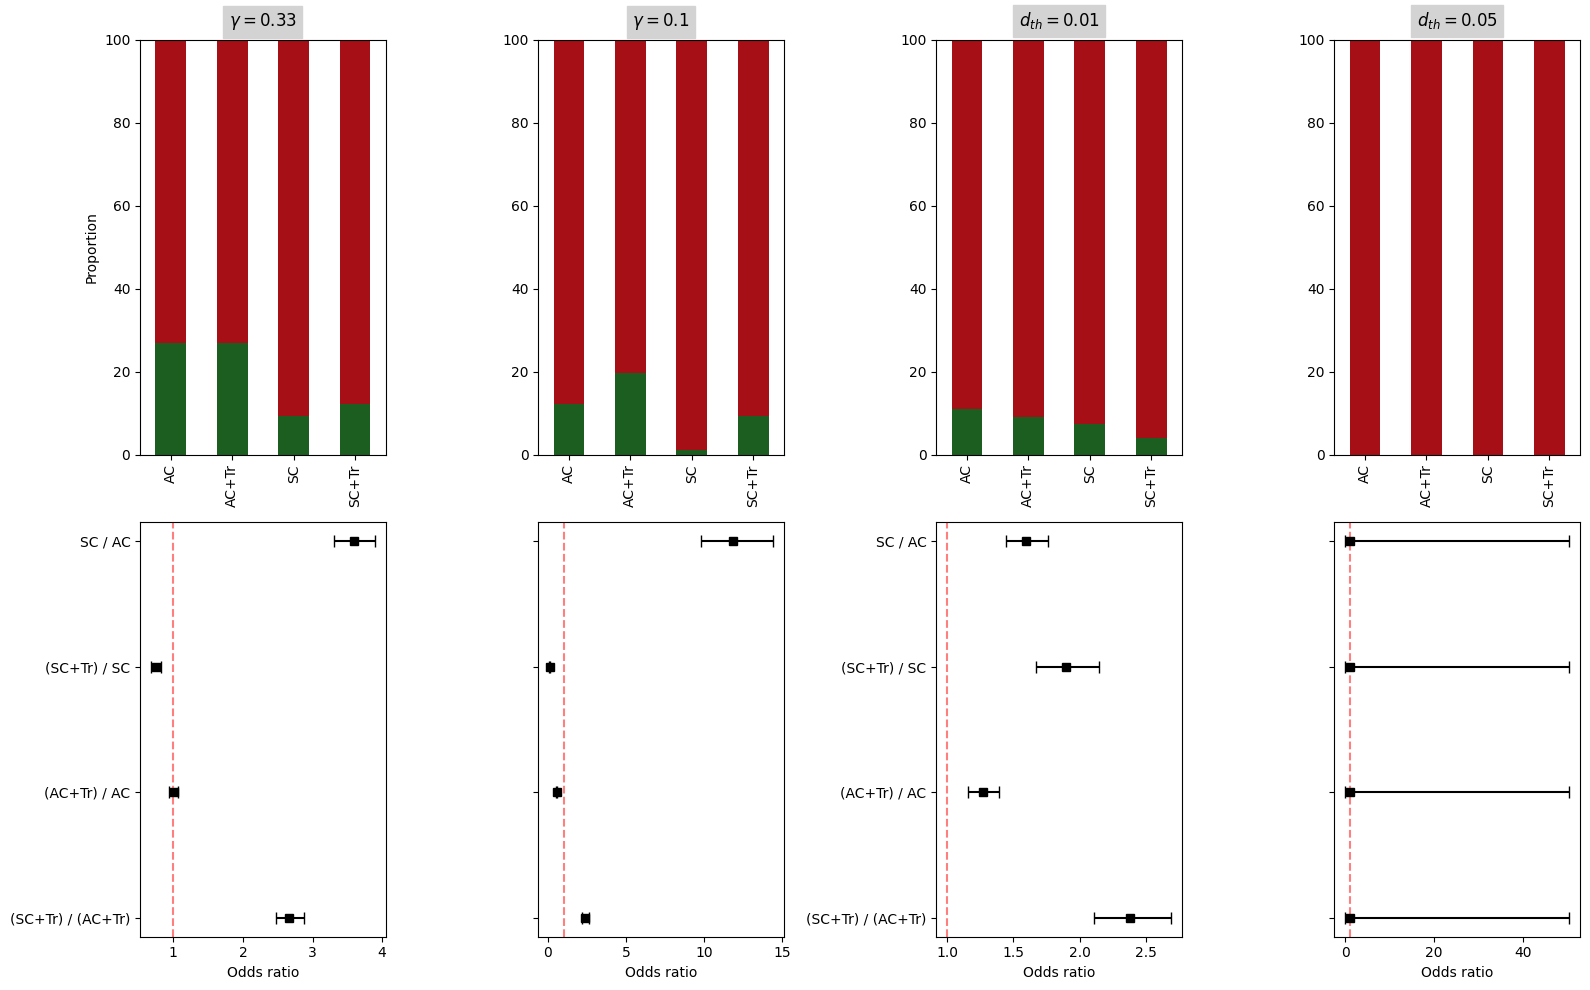

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def log_uniform(low, high, size):
    return np.exp(np.random.uniform(np.log(low), np.log(high), size))

def calc_odds_ratio(df, model_num, model_den):
    counts_num = df[df['Model'] == model_num]['Outcome'].value_counts()
    unfav_num, fav_num = counts_num.get('Unfavourable', 0), counts_num.get('Favourable', 0)
    counts_den = df[df['Model'] == model_den]['Outcome'].value_counts()
    unfav_den, fav_den = counts_den.get('Unfavourable', 0), counts_den.get('Favourable', 0)
    
    unfav_num += 0.5; fav_num += 0.5; unfav_den += 0.5; fav_den += 0.5
    
    OR = (unfav_num / fav_num) / (unfav_den / fav_den)
    se_log_or = np.sqrt(1/unfav_num + 1/fav_num + 1/unfav_den + 1/fav_den)
    return OR, np.exp(np.log(OR) - 1.96 * se_log_or), np.exp(np.log(OR) + 1.96 * se_log_or)

N_SAMPLES = 10000 

rs_v = log_uniform(0.00247, 0.05, N_SAMPLES)
rr_v = log_uniform(0.00247, 0.05, N_SAMPLES)
ts_v = log_uniform(0.000125, 0.0015, N_SAMPLES)
tr_v = log_uniform(0.000125, 0.0015, N_SAMPLES)
ars_v = log_uniform(0.1, 7.4, N_SAMPLES)
asr_v = log_uniform(0.1, 7.4, N_SAMPLES)

therapies = [
    ('Cytostatic', 0.33, 0.0, r'$\gamma = 0.33$'),
    ('Cytostatic', 0.1, 0.0, r'$\gamma = 0.1$'),
    ('Cytotoxic', 1.0, 0.01, r'$d_{th} = 0.01$'),
    ('Cytotoxic', 1.0, 0.05, r'$d_{th} = 0.05$')
]

data_list = []

for idx in range(N_SAMPLES):
    rs, rr = rs_v[idx], rr_v[idx]
    models_params = {
        'AC':    {'a_rs': ars_v[idx], 'a_sr': asr_v[idx], 'ts': 0, 'tr': 0},
        'AC+Tr': {'a_rs': ars_v[idx], 'a_sr': asr_v[idx], 'ts': ts_v[idx], 'tr': tr_v[idx]},
        'SC':    {'a_rs': ars_v[idx], 'a_sr': ars_v[idx], 'ts': 0, 'tr': 0},
        'SC+Tr': {'a_rs': ars_v[idx], 'a_sr': ars_v[idx], 'ts': ts_v[idx], 'tr': tr_v[idx]}
    }
    
    for t_type, gamma, d_th, t_label in therapies:
        for m_name, p in models_params.items():
            sol = solve_ivp(tumor_model_therapy, (0, 5000), [100, 100], 
                            args=(rs, rr, p['a_rs'], p['a_sr'], p['ts'], p['tr'], gamma, d_th), 
                            method='RK45', t_eval=[5000])
            s_end, r_end = sol.y[0][-1], sol.y[1][-1]
            tot = s_end + r_end
            outcome = 'Favourable' if (tot > 0 and s_end/tot > 0.85) else 'Unfavourable'
            data_list.append({'Therapy': t_label, 'Model': m_name, 'Outcome': outcome})
            

df = pd.DataFrame(data_list)

fig = plt.figure(figsize=(16, 10))

for i, (_, _, _, t_label) in enumerate(therapies):
    df_sub = df[df['Therapy'] == t_label]
    
    ax_bar = plt.subplot(2, 4, i+1)
    crosstab = pd.crosstab(df_sub['Model'], df_sub['Outcome'], normalize='index') * 100
    crosstab = crosstab.reindex(['AC', 'AC+Tr', 'SC', 'SC+Tr'])
    if 'Favourable' not in crosstab: crosstab['Favourable'] = 0
    if 'Unfavourable' not in crosstab: crosstab['Unfavourable'] = 0
    crosstab[['Favourable', 'Unfavourable']].plot(kind='bar', stacked=True, 
                                                  color=['#1b5e20', '#a50f15'], ax=ax_bar, legend=False)
    ax_bar.set_title(t_label, backgroundcolor='lightgrey', pad=10)
    ax_bar.set_ylim([0, 100])
    ax_bar.set_xlabel('')
    if i == 0: ax_bar.set_ylabel('Proportion')
    
    ax_or = plt.subplot(2, 4, i+5)
    comps = [('SC', 'AC', 'SC / AC'), ('SC+Tr', 'SC', '(SC+Tr) / SC'), 
             ('AC+Tr', 'AC', '(AC+Tr) / AC'), ('SC+Tr', 'AC+Tr', '(SC+Tr) / (AC+Tr)')]
    y_pos = np.arange(len(comps))
    
    for j, (num, den, label) in enumerate(comps):
        OR, low, up = calc_odds_ratio(df_sub, num, den)
        ax_or.errorbar(OR, j, xerr=[[OR-low], [up-OR]], fmt='s', color='black', capsize=4)
        
    ax_or.axvline(x=1.0, color='red', linestyle='--', alpha=0.5)
    ax_or.set_yticks(y_pos)
    if i == 0 or i == 2: ax_or.set_yticklabels([l for _,_,l in comps])
    else: ax_or.set_yticklabels([])
    ax_or.invert_yaxis()
    ax_or.set_xlabel('Odds ratio')

plt.tight_layout()
plt.savefig('FIG2AB.png', dpi=300, bbox_inches='tight')
plt.show()

## Commenti:

**Grafici A**: Notiamo che più è alta la dose del farmaco, che sia citostatico o citotossico il risultato è lo stesso: le cellule sensibili muoiono più velocemente, favorendo così lo sviluppo "indisturbato" delle cellule resistenti. Si nota che somministrando la dose corrispondente al parametro ($d_{th} = 0.05$) del farmaco citotossico, lo sviluppo delle cellule sensibili viene completamente neutralizzato, quindi portando a 0 esiti positivi. 

**Grafici B**: Questi grafici rispecchiano perfettamente ciò che si può osservare dai grafici del pannello A, come prima stiamo mettendo a confronto diversi scenari. Anche qui, quando inseriamo nell'ODE il parametro ($d_{th} = 0.05$) si hanno 0 esiti favorevoli. Quindi non c'è nessuna differenza statistica tra i diversi modelli (AC, SC, ...).

*Nota*: probabilmente gli autori del paper hanno ottenuto solo 1 risultato favorevole sulle N >> 1 simulazioni che hanno eseguito con il parametro ($d_{th} = 0.05$), poiché hanno ottenuto due rapporti identici rispettivamente per SC/AC e (SC + Tr)/(AC + Tr). Inoltre, rispetto ai risultati ottenuti dai ricercatori i grafici che ho ottenuto relativi ai parametri $\gamma = 0.33$ e $\gamma = 0.1$ sembrano invertiti. Tuttavia, l'impiego di una dose citostatica più aggressiva ($\gamma = 0.1$) dovrebbe portare a un minor numero di esiti favorevoli a causa del più rapido rilascio competitivo delle cellule resistenti. Quindi non capisco se ho sbagliato io o se potrebbe esserci un piccolo errore nel paper.

## Terapia adattiva
Nella **Terapia Adattativa (AT)**, l'obiettivo non è eradicare il tumore, ma tenerlo sotto controllo sfruttando la competizione ecologica tra le cellule. Il farmaco viene somministrato seguendo una logica a "termostato" basata sulla capacità portante ($K$) del sistema:
* **Farmaco ON:** Si attiva quando il volume tumorale totale supera il **50%** di $K$.
* **Farmaco OFF:** Si interrompe quando il volume tumorale scende sotto il **10%** di $K$ (o sotto il **25%** in alcuni scenari).

### Come funziona
Nel codice ho definito una funzione che prendendo diversi parametri iniziali restituisce il risultato del sistema di ODE. Ci aspettiamo che sotto alcune condizioni il tumore risponda bene alla terapia, generando dei cicli dove le cellule sensibile vengono uccise dal farmaco per poi ricrescere quando esso non viene più somministrato.

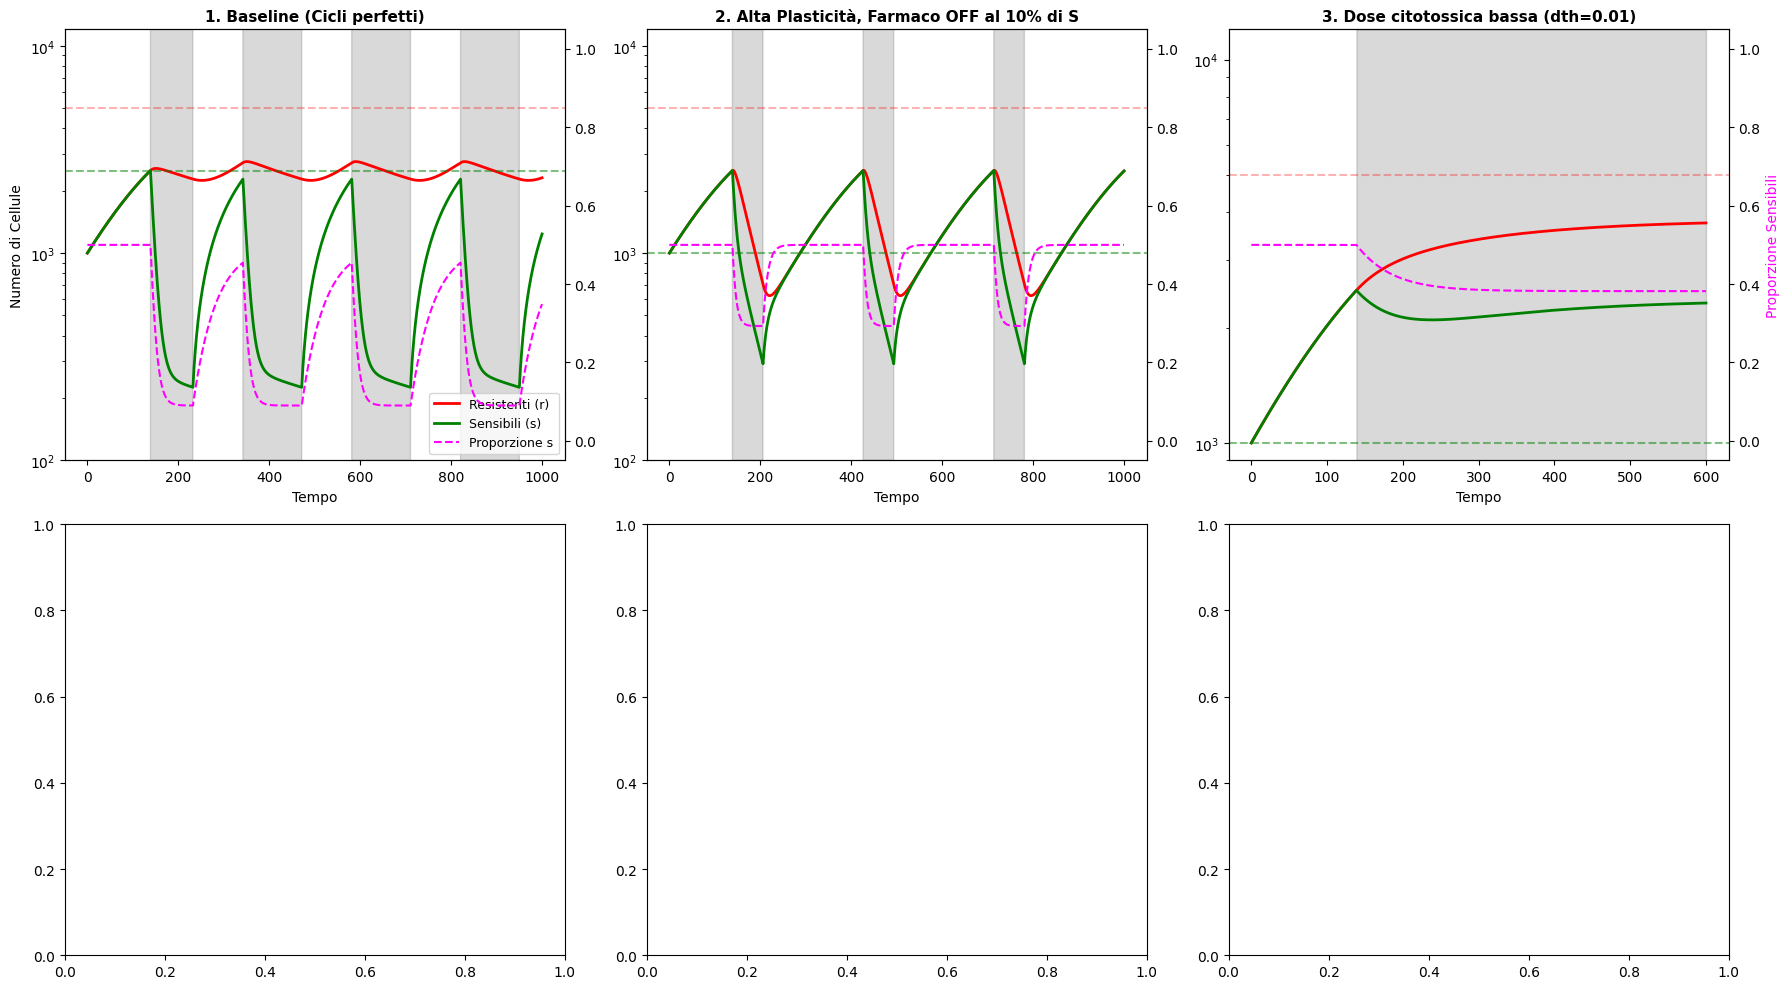

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Funzione separata per le derivate (come il parametro 'func' degli autori)
def tumor_model_derivatives(X, t, rs, rr, alpha_rs, alpha_sr, K, ts, tr, ds):
    s, r = max(0, X[0]), max(0, X[1])
    ds_dt = rs * s * (1 - (s + alpha_rs * r) / K) - ts * s + tr * r - ds * s
    dr_dt = rr * r * (1 - (r + alpha_sr * s) / K) + ts * s - tr * r
    return np.array([ds_dt, dr_dt])

# 2. Funzione principale adattata allo stile degli autori
def advanced_adaptive_therapy(t_max=1000, dt=0.1, 
                              alpha_rs=1.0, alpha_sr=1.0, 
                              rs=0.01, rr=0.01, 
                              ts=0.01, tr=0.01, 
                              rs_treat_val=None, ts_treat_val=None, ds_treat=0.1, 
                              thresh_off_pct=0.25):
    
    # Preparazione parametri
    K = 10000
    thresh_treatment_on = 0.50
    thresh_treatment_off = thresh_off_pct 
    
    rs_treat = rs_treat_val if rs_treat_val is not None else rs
    ts_treat = ts_treat_val if ts_treat_val is not None else ts
    
    # Setup del tempo
    nt = int(t_max / dt)
    time = np.linspace(0, t_max, nt)
    
    # Strutture dati identiche a quelle degli autori
    X = np.zeros((nt, 2), dtype=np.float64)
    X[0, :] = [1000, 1000] # X0
    treatment = np.zeros(nt, dtype=np.int16)
    
    # Inizializzazione dei parametri 'correnti'
    rs_current = rs
    ts_current = ts
    ds_current = 0.0
    
    # Ciclo RK4
    for i in range(nt - 1):
        t_i = time[i]
        
        # Calcolo dei 4 stadi
        k1 = tumor_model_derivatives(X[i], t_i, rs_current, rr, alpha_rs, alpha_sr, K, ts_current, tr, ds_current)
        k2 = tumor_model_derivatives(X[i] + dt*k1/2., t_i + dt/2., rs_current, rr, alpha_rs, alpha_sr, K, ts_current, tr, ds_current)
        k3 = tumor_model_derivatives(X[i] + dt*k2/2., t_i + dt/2., rs_current, rr, alpha_rs, alpha_sr, K, ts_current, tr, ds_current)
        k4 = tumor_model_derivatives(X[i] + dt*k3, t_i + dt, rs_current, rr, alpha_rs, alpha_sr, K, ts_current, tr, ds_current)
        
        # Avanzamento dello stato
        X[i+1] = X[i] + dt / 6. * (k1 + 2. * k2 + 2. * k3 + k4)
        
        # Logica di accensione/spegnimento post-integrazione
        if sum(X[i+1]) > thresh_treatment_on * K and treatment[i] == 0:
            rs_current = rs_treat
            ts_current = ts_treat
            ds_current = ds_treat
            treatment[i+1] = 1
        elif sum(X[i+1]) < thresh_treatment_off * K and treatment[i] == 1:
            rs_current = rs
            ts_current = ts
            ds_current = 0.0
            treatment[i+1] = 0
        else:
            treatment[i+1] = treatment[i]
            
    # Estraiamo s ed r dalla matrice X per renderli compatibili con il tuo blocco di plotting
    return time, X[:, 0], X[:, 1], treatment

scenari = [
    {
        "nome": "1. Baseline (Cicli perfetti)",
        "params": {"alpha_rs": 1, "alpha_sr": 1, "ts": 0.01, "tr": 0.01, "ds_treat": 0.1, "thresh_off_pct": 0.25}
    },
    {
        "nome": "2. Alta Plasticità, Farmaco OFF al 10% di S",
        "params": {"alpha_rs": 1, "alpha_sr": 1, "ts": 0.05, "tr": 0.05, "ds_treat": 0.1, "thresh_off_pct": 0.1}
    },
    {
        "nome": "3. Dose citotossica bassa (dth=0.01)",
        "params": {
            "alpha_rs": 1.0,
            "alpha_sr": 1.0, 
            "rs": 0.01,
            "rr": 0.01,
            "ts": 0.01, 
            "tr": 0.01, 
            "ds_treat": 0.01, 
            "thresh_off_pct": 0.1,
        }
    }
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, sc in enumerate(scenari):
    ax1 = axes[idx]
    if idx <= 1:
        time, s, r, treat = advanced_adaptive_therapy(t_max = 1000, **sc["params"])
    else:
        time, s, r, treat = advanced_adaptive_therapy(t_max = 600, **sc["params"])
    
    ax1.plot(time, r, label='Resistenti (r)', color='red', lw=2)
    ax1.plot(time, s, label='Sensibili (s)', color='green', lw=2)
    
    if idx <= 1:
        y_min, y_max = 100, 12000
    else:
        y_min, y_max = 900, 12000
    ax1.set_ylim(y_min, y_max)
    ax1.set_yscale('log')
    ax1.fill_between(time, y_min, y_max, where=treat==1, color='black', alpha=0.15, step='mid')
    
    ax1.axhline(5000, color='red', linestyle='--', alpha=0.3)
    ax1.axhline(sc["params"]["thresh_off_pct"]*10000, color='green', linestyle='--', alpha=0.5)
    
    ax2 = ax1.twinx()
    prop_s = s / (s + r)
    ax2.plot(time, prop_s, color='#FF00FF', linestyle='--', lw=1.5, label='Proporzione s')
    
    ax2.set_ylim(-0.05, 1.05) 
    
    ax1.set_title(sc["nome"], fontweight='bold', fontsize=11)
    
    if idx >= 0: 
        ax1.set_xlabel("Tempo")
    if idx % 3 == 0: 
        ax1.set_ylabel("Numero di Cellule")
    if idx % 3 == 2: 
        ax2.set_ylabel("Proporzione Sensibili", color='#FF00FF')
        
    if idx == 0: 
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('FIG3CD_RK4.png', dpi=300, bbox_inches='tight')
plt.show()

## Commenti:
Ho notato guardando il codice sorgente postato nella sezione data availability del paper che gli autori hanno fatto diverse simulazioni, variando i valori dei parametri per fare più analisi. Gli autori affermano di aver impostato la threshold per la quale si spegne la somministrazione del farmaco al 10% della popolazione totale, ma riproducendo i risultati e verificando con il codice sorgente degli autori probabilmente il grafico del pannello D usa una threshold del 25%. Ho fatto diverse simulazioni con parametri diversi per vedere come cambiavano i grafici al variare degli scenari.

Qui i grafici che riproducono quelli usati nel paper sono il primo e l'ultimo. Gli scenari 1 e 3 ciclano solo con la threshold-off impostata al 25%, mentre lo scenario 2 cicla sia per 10% che 25%.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files_da_leggere = [
    "AT-cytostatic-0.33.csv",
    "AT-cytostatic-0.33-zero-delay-r1.csv",
    "AT-cytostatic-0.33-zero-delay-r2.csv",
]

dati_raccolti = []

for nome_file in files_da_leggere:
    try:
        df = pd.read_csv(nome_file, header=0)
        dati_raccolti.append(df)
    except FileNotFoundError:
        print(f"ATTENZIONE: Non trovo il file {nome_file}")

display(df)

#Uniamo i dati per creare un data frame
df_tot = pd.concat(dati_raccolti, ignore_index=True)

df_tot['Period'] = pd.to_numeric(df_tot['Period'], errors='coerce')

# c, d = competizione | a, b = plasticità
is_sym = np.isclose(df_tot['c'], df_tot['d'], atol=1e-4)
has_tr = (df_tot['a'] > 1e-6) | (df_tot['b'] > 1e-6)

df_tot['Modello'] = 'Unknown'
df_tot.loc[is_sym & ~has_tr, 'Modello'] = 'SC'
df_tot.loc[is_sym & has_tr, 'Modello'] = 'SC+Tr'
df_tot.loc[~is_sym & ~has_tr, 'Modello'] = 'AC'
df_tot.loc[~is_sym & has_tr, 'Modello'] = 'AC+Tr'

df_tot['Terapia'] = 'Unknown'
#Terapie citotossiche
df_tot.loc[np.isclose(df_tot['cell_death'], 0.01), 'Terapia'] = r"$d_{th} = 0.01$"
df_tot.loc[np.isclose(df_tot['cell_death'], 0.05), 'Terapia'] = r"$d_{th} = 0.05$"

#Terapie citostatiche
df_tot.loc[(df_tot['g_scale'] > 2.9) & (df_tot['g_scale'] < 3.1), 'Terapia'] = r"$\gamma = 0.33$"
df_tot.loc[(df_tot['g_scale'] > 9.9) & (df_tot['g_scale'] < 10.1), 'Terapia'] = r"$\gamma = 0.1$"

df_tot = df_tot[df_tot['Terapia'] != 'Unknown']

#Classificazione esito
is_cycling = ~np.isinf(df_tot['Period']) & df_tot['Period'].notna() & (df_tot['Period'] > 0)
df_tot['Esito'] = 'Favourable'
df_tot.loc[is_cycling, 'Esito'] = 'Cycling'
df_tot.loc[(~is_cycling) & (df_tot['ResFraction'] > 0.15), 'Esito'] = 'Unfavourable'

percentuali_dettagliate = (
    df_tot.groupby(['Terapia', 'Modello'])['Esito']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

print("\n--- Percentuali degli Esiti per Terapia e Modello ---")
print(percentuali_dettagliate.round(2))

,Unnamed: 0,r_x,r_y,a,b,c,d,t_delay,g_scale,cell_death,sen,res,ResFraction,Period,PopSizeSS
0,0,0.034005,0.021372,0.001670,0.004674,1.120350,0.719087,0.0,3.0,0.0,6442.536572,4339.960131,0.402500,inf,10782.496703
1,1,0.020661,0.025270,0.003851,0.001729,2.644987,2.080447,0.0,3.0,0.0,1146.481202,7173.973028,0.862209,inf,8320.454230
2,2,0.027940,0.036002,0.004638,0.004489,0.516507,3.311238,0.0,3.0,0.0,5301.561482,717.516913,0.119207,inf,6019.078395
3,3,0.033370,0.002760,0.000331,0.001924,1.152259,2.622560,0.0,3.0,0.0,9209.876911,510.650966,0.052533,inf,9720.527877
4,4,0.014327,0.029571,0.002270,0.001745,0.962819,2.402551,0.0,3.0,0.0,5001.896141,1050.010045,0.173501,inf,6051.906186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39995,0.034818,0.008703,0.000000,0.000000,0.168076,0.168076,0.0,3.0,0.0,8561.087745,8561.087796,0.500000,inf,17122.175541
39996,39996,0.032024,0.037760,0.000000,0.000000,0.202406,0.202406,0.0,3.0,0.0,8316.660824,8316.661055,0.500000,inf,16633.321879
39997,39997,0.002712,0.026976,0.000000,0.000000,0.416553,0.416553,0.0,3.0,0.0,926.617716,9620.721526,0.912147,inf,10547.339242
39998,39998,0.009635,0.006274,0.000000,0.000000,0.358612,0.358612,0.0,3.0,0.0,7360.691104,7360.309668,0.499987,inf,14721.000772



--- Percentuali degli Esiti per Terapia e Modello ---
Esito                    Favourable  Unfavourable
Terapia         Modello                          
$\gamma = 0.33$ AC            41.02         58.98
                AC+Tr         29.88         70.12
                SC            31.89         68.11
                SC+Tr         22.95         77.05


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files_da_leggere = ["AT-cytostatic-0.1.csv",
    "AT-cytostatic-0.1-zero-delay-r1.csv",
    "AT-cytostatic-0.1-zero-delay-r3.csv"]

dati_raccolti = []

for nome_file in files_da_leggere:
    try:
        df = pd.read_csv(nome_file, header=0)
        dati_raccolti.append(df)
    except FileNotFoundError:
        print(f"ATTENZIONE: Non trovo il file {nome_file}")

display(df)

#Uniamo i dati per creare un data frame
df_tot = pd.concat(dati_raccolti, ignore_index=True)

df_tot['Period'] = pd.to_numeric(df_tot['Period'], errors='coerce')

# c, d = competizione | a, b = plasticità
is_sym = np.isclose(df_tot['c'], df_tot['d'], atol=1e-4)
has_tr = (df_tot['a'] > 1e-6) | (df_tot['b'] > 1e-6)

df_tot['Modello'] = 'Unknown'
df_tot.loc[is_sym & ~has_tr, 'Modello'] = 'SC'
df_tot.loc[is_sym & has_tr, 'Modello'] = 'SC+Tr'
df_tot.loc[~is_sym & ~has_tr, 'Modello'] = 'AC'
df_tot.loc[~is_sym & has_tr, 'Modello'] = 'AC+Tr'

df_tot['Terapia'] = 'Unknown'
#Terapie citotossiche
df_tot.loc[np.isclose(df_tot['cell_death'], 0.01), 'Terapia'] = r"$d_{th} = 0.01$"
df_tot.loc[np.isclose(df_tot['cell_death'], 0.05), 'Terapia'] = r"$d_{th} = 0.05$"

#Terapie citostatiche
df_tot.loc[(df_tot['g_scale'] > 2.9) & (df_tot['g_scale'] < 3.1), 'Terapia'] = r"$\gamma = 0.33$"
df_tot.loc[(df_tot['g_scale'] > 9.9) & (df_tot['g_scale'] < 10.1), 'Terapia'] = r"$\gamma = 0.1$"

df_tot = df_tot[df_tot['Terapia'] != 'Unknown']

#Classificazione esito
is_cycling = ~np.isinf(df_tot['Period']) & df_tot['Period'].notna() & (df_tot['Period'] > 0)
df_tot['Esito'] = 'Favourable'
df_tot.loc[is_cycling, 'Esito'] = 'Cycling'
df_tot.loc[(~is_cycling) & (df_tot['ResFraction'] > 0.15), 'Esito'] = 'Unfavourable'

percentuali_dettagliate = (
    df_tot.groupby(['Terapia', 'Modello'])['Esito']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

print("\n--- Percentuali degli Esiti per Terapia e Modello ---")
print(percentuali_dettagliate.round(2))

,Unnamed: 0,r_x,r_y,a,b,c,d,t_delay,g_scale,cell_death,sen,res,ResFraction,Period,PopSizeSS
0,0,0.040271,0.045046,0.001982,0.000584,3.519466,2.781301,0.0,10.0,0.0,486.152144,8543.299939,0.946159,inf,9029.452083
1,1,0.024878,0.045312,0.004542,0.000294,3.274207,3.220155,0.0,10.0,0.0,280.496105,9062.850774,0.969979,inf,9343.346880
2,2,0.012948,0.019283,0.002523,0.003371,0.275342,2.969878,0.0,10.0,0.0,3129.730110,1568.016686,0.333781,inf,4697.746795
3,3,0.026692,0.009546,0.003943,0.001748,3.832617,0.552989,0.0,10.0,0.0,1424.857873,8106.560467,0.850509,inf,9531.418340
4,4,0.017072,0.021017,0.002230,0.002668,2.078638,2.072619,0.0,10.0,0.0,3517.375277,2781.755356,0.441609,inf,6299.130633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39995,0.008873,0.031595,0.000000,0.000000,0.237646,0.237646,0.0,10.0,0.0,3355.152519,9213.431460,0.733052,inf,12568.583979
39996,39996,0.018852,0.005513,0.000000,0.000000,4.505581,4.505581,0.0,10.0,0.0,9998.589767,0.000000,0.000000,inf,9998.589767
39997,39997,0.012137,0.010571,0.000000,0.000000,5.146896,5.146896,0.0,10.0,0.0,9952.706803,0.000000,0.000000,inf,9952.706803
39998,39998,0.021983,0.005538,0.000000,0.000000,0.267623,0.267623,0.0,10.0,0.0,7891.673171,7887.586237,0.499870,inf,15779.259408



--- Percentuali degli Esiti per Terapia e Modello ---
Esito                   Favourable  Unfavourable
Terapia        Modello                          
$\gamma = 0.1$ AC            36.52         63.48
               AC+Tr         19.76         80.24
               SC            30.36         69.64
               SC+Tr         16.86         83.14



--- Percentuali degli Esiti per Terapia e Modello ---
Esito                    Cycling  Favourable  Unfavourable
Terapia         Modello                                   
$\gamma = 0.1$  AC          0.00       36.52         63.48
                AC+Tr       0.00       19.76         80.24
                SC          0.00       30.36         69.64
                SC+Tr       0.00       16.86         83.14
$\gamma = 0.33$ AC          0.00       41.02         58.98
                AC+Tr       0.00       29.88         70.12
                SC          0.00       31.89         68.11
                SC+Tr       0.00       22.95         77.05
$d_{th} = 0.01$ AC          0.00       24.21         75.79
                AC+Tr       0.00       12.63         87.37
                SC          0.00       20.77         79.23
                SC+Tr       0.00        8.18         91.82
$d_{th} = 0.05$ AC          3.53        1.33         95.14
                AC+Tr       1.70        0.84         97.46
 

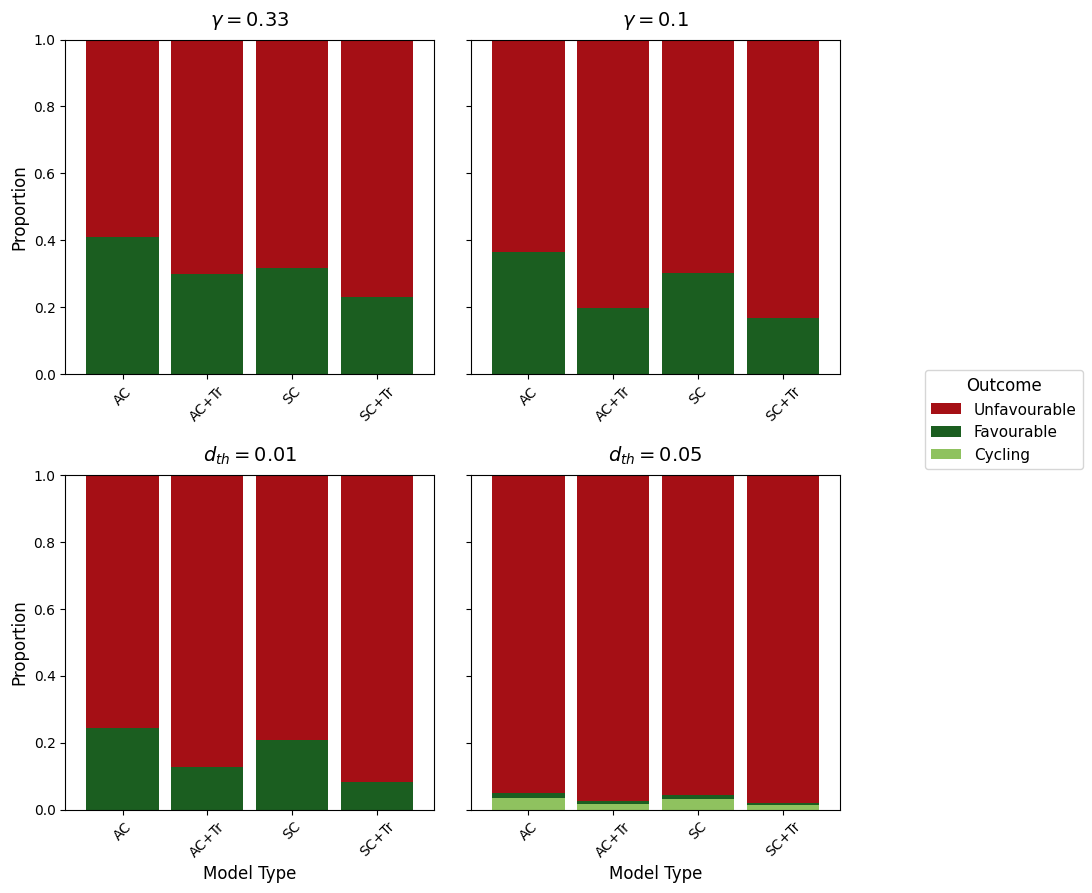

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files_da_leggere = [
    "AT-cytostatic-0.33.csv",
    "AT-cytostatic-0.33-zero-delay-r1.csv",
    "AT-cytostatic-0.33-zero-delay-r2.csv",
    "AT-cytostatic-0.1.csv",
    "AT-cytostatic-0.1-zero-delay-r1.csv",
    "AT-cytostatic-0.1-zero-delay-r3.csv",
    "AT-cytotoxic-0.01.csv",
    "AT-cytotoxic-0.01-zero-delay-r1.csv",
    "AT-cytotoxic-0.01-zero-delay-r3.csv",
    "AT-cytotoxic-0.05.csv",
    "AT-cytotoxic-0.05-zero-delay-r2.csv",
    "AT-cytotoxic-0.05-zero-delay-r3.csv"
]

dati_raccolti = []

for nome_file in files_da_leggere:
    try:
        df = pd.read_csv(nome_file, header=0)
        dati_raccolti.append(df)
    except FileNotFoundError:
        print(f"ATTENZIONE: Non trovo il file {nome_file}")
        
#Uniamo i dati per creare un data frame
df_tot = pd.concat(dati_raccolti, ignore_index=True)

df_tot['Period'] = pd.to_numeric(df_tot['Period'], errors='coerce')

# c, d = competizione | a, b = plasticità
is_sym = np.isclose(df_tot['c'], df_tot['d'], atol=1e-4)
has_tr = (df_tot['a'] > 1e-6) | (df_tot['b'] > 1e-6)

df_tot['Modello'] = 'Unknown'
df_tot.loc[is_sym & ~has_tr, 'Modello'] = 'SC'
df_tot.loc[is_sym & has_tr, 'Modello'] = 'SC+Tr'
df_tot.loc[~is_sym & ~has_tr, 'Modello'] = 'AC'
df_tot.loc[~is_sym & has_tr, 'Modello'] = 'AC+Tr'

df_tot['Terapia'] = 'Unknown'

#Terapie citotossiche
df_tot.loc[np.isclose(df_tot['cell_death'], 0.01), 'Terapia'] = r"$d_{th} = 0.01$"
df_tot.loc[np.isclose(df_tot['cell_death'], 0.05), 'Terapia'] = r"$d_{th} = 0.05$"

#Terapie citostatiche
df_tot.loc[(df_tot['g_scale'] > 2.9) & (df_tot['g_scale'] < 3.1), 'Terapia'] = r"$\gamma = 0.33$"
df_tot.loc[(df_tot['g_scale'] > 9.9) & (df_tot['g_scale'] < 10.1), 'Terapia'] = r"$\gamma = 0.1$"

df_tot = df_tot[df_tot['Terapia'] != 'Unknown']

#Classificazione esito
is_cycling = ~np.isinf(df_tot['Period']) & df_tot['Period'].notna() & (df_tot['Period'] > 0)
df_tot['Esito'] = 'Favourable'
df_tot.loc[is_cycling, 'Esito'] = 'Cycling'
df_tot.loc[(~is_cycling) & (df_tot['ResFraction'] > 0.15), 'Esito'] = 'Unfavourable'

percentuali_dettagliate = (
    df_tot.groupby(['Terapia', 'Modello'])['Esito']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

print("\n--- Percentuali degli Esiti per Terapia e Modello ---")
print(percentuali_dettagliate.round(2))

therapies_order = [
    r"$\gamma = 0.33$", r"$\gamma = 0.1$", 
    r"$d_{th} = 0.01$", r"$d_{th} = 0.05$"
]
modelli_order = ["AC", "AC+Tr", "SC", "SC+Tr"]
esiti_order = ['Cycling', 'Favourable', 'Unfavourable']

colori = {'Unfavourable': '#a50f15', 'Favourable': '#1b5e20', 'Cycling': '#8fc25f'}

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
axes = axes.flatten()

for idx, th in enumerate(therapies_order): 
    ax = axes[idx]
    df_sub = df_tot[df_tot["Terapia"] == th]
    df_plot = df_sub.groupby(['Modello', 'Esito']).size().unstack(fill_value=0)
    
    for col in esiti_order:
        if col not in df_plot: df_plot[col] = 0
            
    df_plot = df_plot.div(df_plot.sum(axis=1), axis=0)
    df_plot = df_plot[esiti_order]
    df_plot = df_plot.reindex(modelli_order)
    
    df_plot.plot(
        kind='bar', stacked=True, 
        color=[colori[c] for c in esiti_order], 
        ax=ax, width=0.85, legend=False
    )
    
    ax.set_title(th, fontsize=14, fontweight='bold', pad=10)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Proportion" if idx % 2 == 0 else "", fontsize=12)
    ax.set_xlabel("Model Type" if idx >= 2 else "", fontsize=12)
    ax.tick_params(axis='x', rotation=45)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles[::-1], labels[::-1], loc='center right', title="Outcome", 
           bbox_to_anchor=(1.15, 0.5), fontsize=11, title_fontsize=12)

plt.subplots_adjust(wspace=0.1, hspace=0.3)
plt.savefig('FIG3A.png', dpi=300, bbox_inches='tight')
plt.show()

# Commenti:
Ho provato prima a creare una simulazione che potesse emulare quanto fatto dagli autori (guardando anche il loro codice) e poi invece ho preso i dati generati dalla loro simulazione e ho provato a generare i grafici usando questi ultimi. Anche qui i risultati della terapia citostatica vengono invertiti, ma non capisco perché. Ho provato pure a printare le percentuali prima di plottare i grafici, ma anche così facendo non riesco a capire perché i risultati mostrano questa incongruenza.

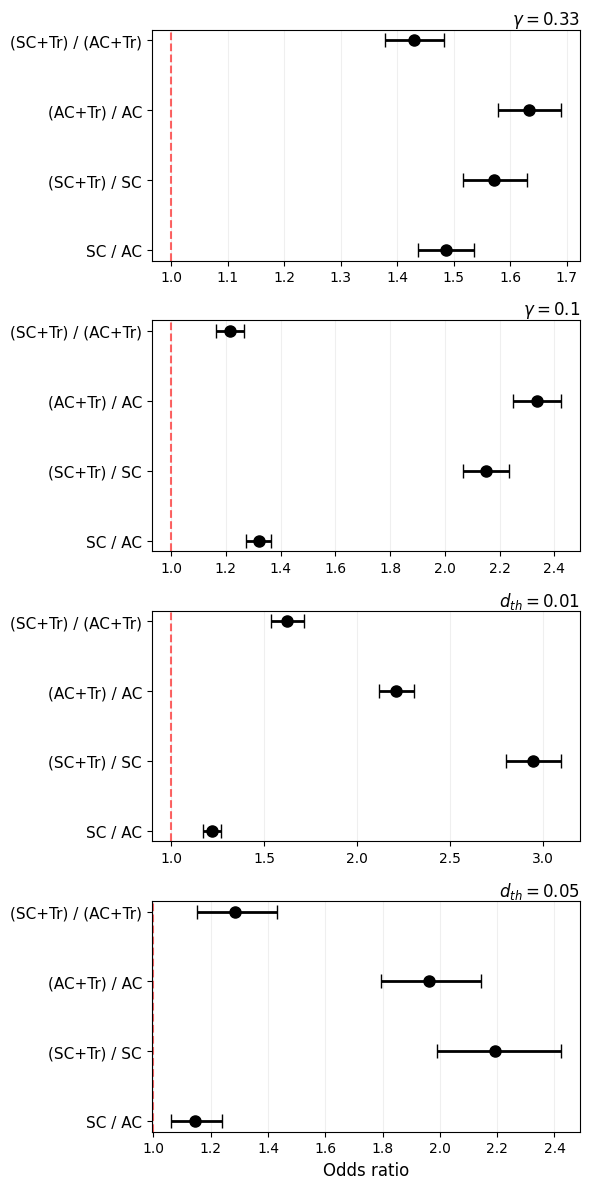

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files_da_leggere = [
    "AT-cytostatic-0.33.csv", "AT-cytostatic-0.33-zero-delay-r1.csv", "AT-cytostatic-0.33-zero-delay-r2.csv",
    "AT-cytostatic-0.1.csv", "AT-cytostatic-0.1-zero-delay-r1.csv", "AT-cytostatic-0.1-zero-delay-r3.csv",
    "AT-cytotoxic-0.01.csv", "AT-cytotoxic-0.01-zero-delay-r1.csv", "AT-cytotoxic-0.01-zero-delay-r3.csv",
    "AT-cytotoxic-0.05.csv", "AT-cytotoxic-0.05-zero-delay-r2.csv", "AT-cytotoxic-0.05-zero-delay-r3.csv"
]

dati_raccolti = []

for nome_file in files_da_leggere:
    try:
        df = pd.read_csv(nome_file)
        dati_raccolti.append(df)
    except FileNotFoundError:
        print(f"File non trovato: {nome_file}")

if not dati_raccolti:
    print("Errore: Nessun file caricato. Verifica di essere nella cartella corretta.")
else:
    df_tot = pd.concat(dati_raccolti, ignore_index=True)

    is_sym = np.isclose(df_tot['c'], df_tot['d'], atol=1e-4)
    has_tr = (df_tot['a'] > 1e-6) | (df_tot['b'] > 1e-6)

    df_tot['Modello'] = 'Unknown'
    df_tot.loc[is_sym & ~has_tr, 'Modello'] = 'SC'
    df_tot.loc[is_sym & has_tr, 'Modello'] = 'SC+Tr'
    df_tot.loc[~is_sym & ~has_tr, 'Modello'] = 'AC'
    df_tot.loc[~is_sym & has_tr, 'Modello'] = 'AC+Tr'

    #Terapia
    df_tot['Terapia'] = 'Unknown'
    df_tot.loc[np.isclose(df_tot['cell_death'], 0.01), 'Terapia'] = r"$d_{th} = 0.01$"
    df_tot.loc[np.isclose(df_tot['cell_death'], 0.05), 'Terapia'] = r"$d_{th} = 0.05$"
    df_tot.loc[(df_tot['g_scale'] > 2.9) & (df_tot['g_scale'] < 3.1), 'Terapia'] = r"$\gamma = 0.33$"
    df_tot.loc[(df_tot['g_scale'] > 9.9) & (df_tot['g_scale'] < 10.1), 'Terapia'] = r"$\gamma = 0.1$"

    df_tot['Period'] = pd.to_numeric(df_tot['Period'], errors='coerce')
    is_cycling = ~np.isinf(df_tot['Period']) & df_tot['Period'].notna() & (df_tot['Period'] > 0)
    df_tot['Is_Fail'] = (df_tot['ResFraction'] > 0.15) & (~is_cycling)

    def get_odds_ratio(df, mod_num, mod_den):
        a = len(df[(df['Modello'] == mod_num) & (df['Is_Fail'] == True)])
        b = len(df[(df['Modello'] == mod_num) & (df['Is_Fail'] == False)])
        c = len(df[(df['Modello'] == mod_den) & (df['Is_Fail'] == True)])
        d = len(df[(df['Modello'] == mod_den) & (df['Is_Fail'] == False)])
        
        a, b, c, d = a+0.5, b+0.5, c+0.5, d+0.5
            
        or_val = (a * d) / (b * c)
        se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
        ci_low = np.exp(np.log(or_val) - 1.96 * se_log_or)
        ci_high = np.exp(np.log(or_val) + 1.96 * se_log_or)
        return or_val, ci_low, ci_high

    comparisons = [
        ("(SC+Tr) / (AC+Tr)", "SC+Tr", "AC+Tr"),
        ("(AC+Tr) / AC", "AC+Tr", "AC"),
        ("(SC+Tr) / SC", "SC+Tr", "SC"),
        ("SC / AC", "SC", "AC")
    ]
    therapies_list = [r"$\gamma = 0.33$", r"$\gamma = 0.1$", r"$d_{th} = 0.01$", r"$d_{th} = 0.05$"]

    fig, axes = plt.subplots(4, 1, figsize=(6, 12), sharex=False)

    for i, th in enumerate(therapies_list):
        ax = axes[i]
        df_th = df_tot[df_tot['Terapia'] == th]
        
        y_labels = []
        for j, (label, num, den) in enumerate(comparisons):
            or_val, low, high = get_odds_ratio(df_th, num, den)
            ax.errorbar(or_val, j, xerr=[[or_val-low], [high-or_val]], 
                        fmt='o', color='black', capsize=5, elinewidth=2, markersize=8)
            y_labels.append(label)
        
        ax.axvline(1.0, color='red', linestyle='--', alpha=0.6)
        ax.set_yticks(range(len(comparisons)))
        ax.set_yticklabels(y_labels, fontsize=11)
        ax.set_title(th, loc='right', fontweight='bold', fontsize=12, pad=-15)
        ax.invert_yaxis()
        ax.grid(True, axis='x', alpha=0.2)
        if i == 3: ax.set_xlabel("Odds ratio", fontsize=12)

    plt.tight_layout()
    plt.savefig('FIG3B.png', dpi=300, bbox_inches='tight')
    plt.show()

## Commenti:
Anche qui i grafici relativi a ${\gamma=0.33}$ e ${\gamma=0.1}$ sono invertiti, coerentemente con i grafici della cella precedente

### Analisi dei Parametri Critici per la Stabilità dei Cicli

L'obiettivo di questa cella è capire quali parametri dei tumori favoriscono la buona riuscita della cura.

#### 1. Filtraggio Selettivo dei Dati
Il codice applicherà un filtro al dataset per isolare solo i pazienti classificati come **Cycling**

#### 2. Analisi del periodo dei cicli (Grafico A)
Utilizziamo i **Boxplot** per confrontare la durata del ciclo di terapia (*Period*) tra i quattro modelli ecologici ($AC$, $AC+Tr$, $SC$, $SC+Tr$). 

#### 3. Caratterizzazione dei parametri (Grafico C)
Generiamo una griglia di **Violin Plots** per visualizzare la densità di probabilità dei 6 parametri fondamentali all'interno del gruppo *Cycling*. La forma ("pancia") di questi violini ci indicherà quali valori sono necessari per il successo.

A differenza del campionamento uniforme originale, le distribuzioni asimmetriche in questi grafici dimostreranno che la Terapia Adattativa non funziona in modo casuale, ma richiede una **specifica configurazione ecologica del tumore**.

          count        mean         std         min         25%         50%  \
Modello                                                                       
AC       1060.0  201.252125  127.740846  142.571429  142.571429  142.571429   
AC+Tr     511.0  245.486982  176.896624  142.571429  142.571429  199.600000   
SC        986.0  204.730740  133.969580  142.571429  142.571429  166.333333   
SC+Tr     428.0  269.408923  198.236816  142.571429  166.333333  199.600000   

           75%    max  
Modello                
AC       199.6  998.0  
AC+Tr    249.5  998.0  
SC       199.6  998.0  
SC+Tr    249.5  998.0  


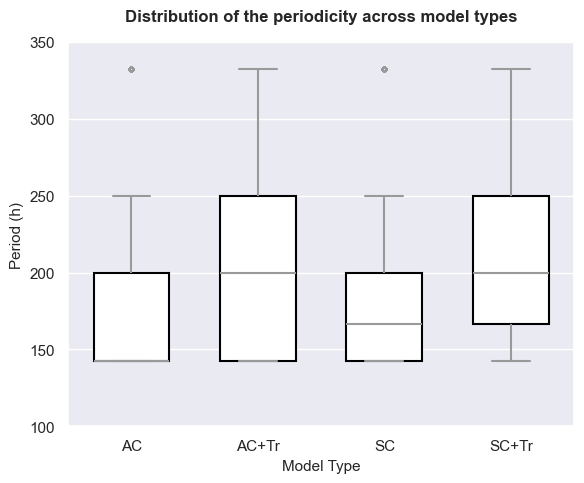

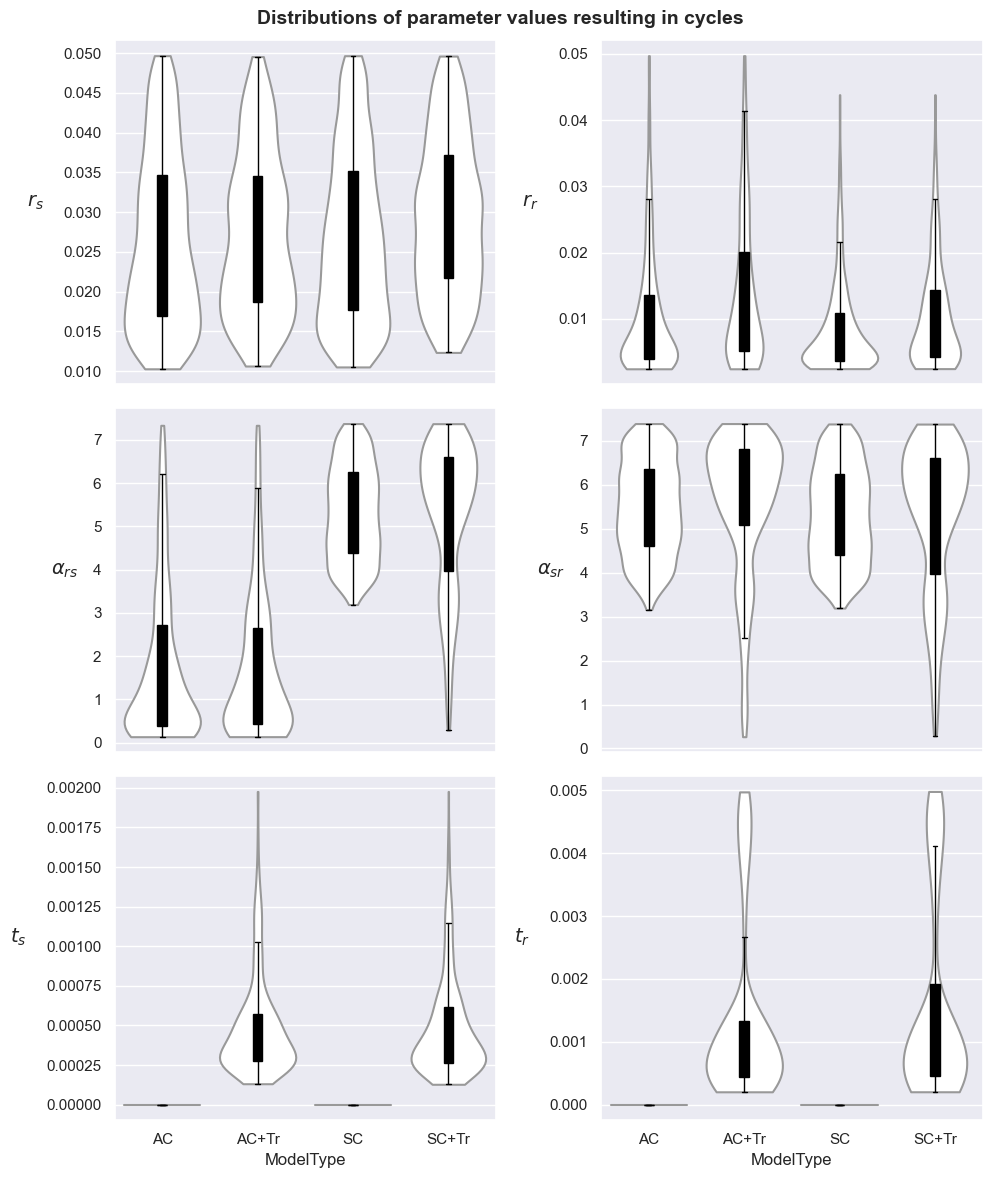

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

files_da_leggere = [
    "AT-cytostatic-0.33.csv", "AT-cytostatic-0.33-zero-delay-r1.csv", "AT-cytostatic-0.33-zero-delay-r2.csv",
    "AT-cytostatic-0.1.csv", "AT-cytostatic-0.1-zero-delay-r1.csv", "AT-cytostatic-0.1-zero-delay-r3.csv",
    "AT-cytotoxic-0.01.csv", "AT-cytotoxic-0.01-zero-delay-r1.csv", "AT-cytotoxic-0.01-zero-delay-r3.csv",
    "AT-cytotoxic-0.05.csv", "AT-cytotoxic-0.05-zero-delay-r2.csv", "AT-cytotoxic-0.05-zero-delay-r3.csv"
]

dati_raccolti = []

for nome_file in files_da_leggere:
    try:
        df = pd.read_csv(nome_file)
        dati_raccolti.append(df)
    except FileNotFoundError:
        print(f"File non trovato: {nome_file}")

if not dati_raccolti:
    print("Errore: Nessun file caricato.")
else:
    df_tot = pd.concat(dati_raccolti, ignore_index=True)

    is_sym = np.isclose(df_tot['c'], df_tot['d'], atol=1e-4)
    has_tr = (df_tot['a'] > 1e-6) | (df_tot['b'] > 1e-6)

    df_tot['Modello'] = 'Unknown'
    df_tot.loc[is_sym & ~has_tr, 'Modello'] = 'SC'
    df_tot.loc[is_sym & has_tr, 'Modello'] = 'SC+Tr'
    df_tot.loc[~is_sym & ~has_tr, 'Modello'] = 'AC'
    df_tot.loc[~is_sym & has_tr, 'Modello'] = 'AC+Tr'

    df_tot['Period'] = pd.to_numeric(df_tot['Period'], errors='coerce')
    is_cycling = ~np.isinf(df_tot['Period']) & df_tot['Period'].notna() & (df_tot['Period'] > 0)
    
    df_cycling = df_tot[is_cycling].copy()
    
    sns.set_theme(style="darkgrid")
    model_order = ["AC", "AC+Tr", "SC", "SC+Tr"]
    
    statistiche = df_cycling.groupby('Modello')['Period'].describe()
    print(statistiche)

    fig_a, ax_a = plt.subplots(figsize=(6, 5))
    
    sns.boxplot(
        x='Modello', y='Period', data=df_cycling, order=model_order, 
        color="white", width=0.6, fliersize=3, linewidth=1.5, ax=ax_a
    )
    
    for patch in ax_a.patches:
        patch.set_edgecolor('black')
        
    ax_a.set_title("Distribution of the periodicity across model types", fontsize=12, fontweight='bold', pad=15)
    ax_a.set_ylabel("Period (h)", fontsize=11)
    ax_a.set_xlabel("Model Type", fontsize=11)

    ax_a.set_ylim(100, 350)
    
    plt.tight_layout()
    plt.show()

    params_to_plot = [
        ('r_x', r'$r_s$'), ('r_y', r'$r_r$'),
        ('c', r'$\alpha_{rs}$'), ('d', r'$\alpha_{sr}$'),
        ('a', r'$t_s$'), ('b', r'$t_r$')
    ]

    fig_c, axes_c = plt.subplots(3, 2, figsize=(10, 12))
    axes_c = axes_c.flatten()

    for i, (col_name, label) in enumerate(params_to_plot):
        ax = axes_c[i]
        
        sns.violinplot(
            x='Modello', y=col_name, data=df_cycling, order=model_order,
            color="white", inner=None, linewidth=1.5, cut=0, ax=ax
        )
        
        sns.boxplot(
            x='Modello', y=col_name, data=df_cycling, order=model_order,
            color="black", width=0.1, boxprops={'zorder': 2}, ax=ax, showfliers=False
        )

        ax.set_ylabel(label, fontsize=14, fontweight='bold', rotation=0, labelpad=20)
        ax.set_xlabel("ModelType" if i >= 4 else "")
        if i < 4:
            ax.set_xticklabels([])

    plt.suptitle("Distributions of parameter values resulting in cycles", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig('FIG4C.png', dpi=300, bbox_inches='tight')
    plt.show()

### Test dei Ranghi con Segno di Wilcoxon
Ho cercato di replicare il Wilcoxon signed-rank test utilizzato dagli autori per verificare che la differenza del periodo dei cicli non sia dovuta al caso.

#### Interpretazione del Risultato (Il p-value)
Il test restituisce un **p-value**, ovvero la probabilità che la differenza osservata sia dovuta al puro caso. Un valore inferiore alla soglia standard ($p < 0.05$) attiva la comparsa dell'asterisco rosso sul grafico. Questo certifica in modo matematicamente inoppugnabile che la plasticità cellulare causa una dilatazione strutturale e prevedibile dei tempi di risposta alla Terapia Adattativa.

 -> Wilcoxon Signed-Rank p-value = 2.39e-39
 -> Wilcoxon Signed-Rank p-value = 1.86e-40


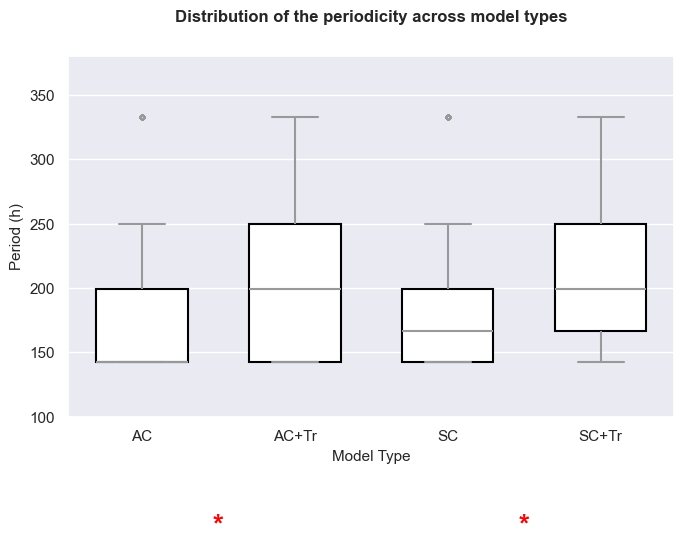

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

sns.set_theme(style="darkgrid")
model_order = ["AC", "AC+Tr", "SC", "SC+Tr"]

df_cycling['Patient_ID'] = df_cycling['r_x'].round(5).astype(str) + "_" + df_cycling['r_y'].round(5).astype(str)

fig_a, ax_a = plt.subplots(figsize=(7, 6))
sns.boxplot(
    x='Modello', y='Period', data=df_cycling, order=model_order, 
    color="white", width=0.6, fliersize=3, linewidth=1.5, ax=ax_a
)

for patch in ax_a.patches:
    patch.set_edgecolor('black')
    
ax_a.set_title("Distribution of the periodicity across model types", fontsize=12, fontweight='bold', pad=25)
ax_a.set_ylabel("Period (h)", fontsize=11)
ax_a.set_xlabel("Model Type", fontsize=11)
ax_a.set_ylim(100, 380)

#TEST DI WILCOXON
def add_paired_stat_annotation(ax, data, group1, group2, x1, x2, h_offset):
    df_pair = data[data['Modello'].isin([group1, group2])]
    pivot_df = df_pair.pivot_table(index='Patient_ID', columns='Modello', values='Period')
    pivot_df_clean = pivot_df.dropna()
    n_pairs = len(pivot_df_clean)

    #TEST
    stat, p_value = wilcoxon(pivot_df_clean[group1], pivot_df_clean[group2])
    print(f" -> Wilcoxon Signed-Rank p-value = {p_value:.2e}")

    #ASTERISCO ROSSO
    if p_value < 0.05:
        y_max = data[data['Modello'].isin([group1, group2])]['Period'].max()
        y_bar = y_max + h_offset
        bar_height = 5
        
        ax.plot([x1, x1, x2, x2], [y_bar, y_bar + bar_height, y_bar + bar_height, y_bar], lw=1.5, color='black')
        ax.text((x1 + x2) * .5,bar_height, "*", ha='center', va='bottom', color='red', fontsize=20, fontweight='bold')

add_paired_stat_annotation(ax_a, df_cycling, 'AC', 'AC+Tr', 0, 1, h_offset=10)
add_paired_stat_annotation(ax_a, df_cycling, 'SC', 'SC+Tr', 2, 3, h_offset=10)

plt.tight_layout()
plt.savefig('FIG4A.png', dpi=300, bbox_inches='tight')
plt.show()

## Commenti: 
Usando i dati del paper, i boxplot vengono leggermente diversi: i plot dei modelli AC e SC sembrano identici ma invertiti (possibile errore del paper?), mentre per quanto riguarda il plot di AC + Tr sembra che qui sia stato ottenuta la base del box ad un'ordinata minore rispetto a quella del paper. Tuttavia la rivelanza del grafico è messa in evidenza allo stesso modo, si vede bene che la mediana dei modelli con le transizioni mostra una durata dei cicli più lunga per essi.
Alla luce di questo, è interessante notare come le transizioni favoriscano lo sviluppo di cicli più lunghi ma abbassino le probabilità di riuscita della terapia (figura 3A). In pratica, per utilizzare la terapia adattiva bisognerebbe avere dati precisissimi sui parametri che ci interessano (figura 4B/C), altrimenti le probabilità di riuscita della cura sono quasi nulle se fatta alla cieca.

I grafici a violino invece sono molto simili.

### Analisi dell'Effect Size: Identikit dei Parametri Critici (Fig. 4B)

L'obiettivo di questo pannello è quantificare statisticamente quali parametri biologici determinano il successo della Terapia Adattativa. A differenza della pura visualizzazione delle distribuzioni, qui calcoliamo l'**Effect Size (d di Cohen)** confrontando direttamente la coorte di pazienti con esito *Cycling* contro il resto della popolazione simulata (*Non-Cycling*).

#### Come funziona
1. **Classificazione Binaria:** Il dataset globale viene diviso in due gruppi in base alla capacità di mantenere oscillazioni stabili.
2. **Calcolo del d di Cohen:** Per ogni parametro ecologico ($r_s, r_r, \alpha_{rs}, \alpha_{sr}, t_s, t_r$) e per ogni tipo di modello, viene calcolata la differenza standardizzata tra le medie dei due gruppi.
3. **Intervalli di Confidenza:** Viene calcolato l'errore standard dell'Effect Size per tracciare le barre di errore con un livello di confidenza del 95%.

#### Come si legge il grafico
* **Linea rossa ($x = 0$):** Indica un effetto nullo (il parametro non influenza la dinamica dei cicli).
* **Punti a destra ($x > 0$):** Valori positivi indicano che il mantenimento dei cicli richiede un valore *più elevato* del parametro (es. forte soppressione $\alpha_{sr}$).
* **Punti a sinistra ($x < 0$):** Valori negativi indicano che i cicli si verificano solo se il parametro è mantenuto a livelli *bassi* (es. basso costo della resistenza $r_r$ e transizioni fenotipiche minime $t_s, t_r$).

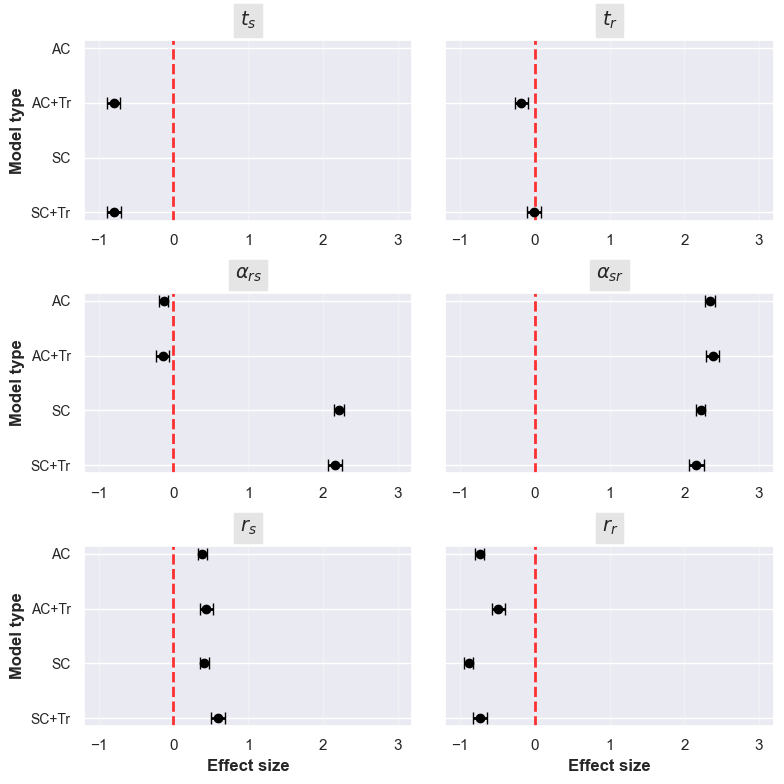

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Definiamo chi "cicla" e chi no
df_tot['Period'] = pd.to_numeric(df_tot['Period'], errors='coerce')
df_tot['Is_Cycling'] = (~np.isinf(df_tot['Period'])) & (df_tot['Period'].notna()) & (df_tot['Period'] > 0)

model_order = ["SC+Tr", "SC", "AC+Tr", "AC"]

parameters = [
    ('a', r'$t_s$'), ('b', r'$t_r$'),
    ('c', r'$\alpha_{rs}$'), ('d', r'$\alpha_{sr}$'),
    ('r_x', r'$r_s$'), ('r_y', r'$r_r$')
]

def compute_cohens_d(df, param, model_name):
    sub_df = df[df['Modello'] == model_name]
    
    group_cycling = sub_df[sub_df['Is_Cycling'] == True][param].dropna()
    group_non_cycling = sub_df[sub_df['Is_Cycling'] == False][param].dropna()
    
    n1, n2 = len(group_cycling), len(group_non_cycling)
        
    m1, m2 = np.mean(group_cycling), np.mean(group_non_cycling)
    v1, v2 = np.var(group_cycling, ddof=1), np.var(group_non_cycling, ddof=1)
    
    if v1 == 0 and v2 == 0:
        return np.nan, np.nan
        
    #Deviazione standard aggregata
    sd_pooled = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    
    if sd_pooled == 0:
        return np.nan, np.nan
        
    #Calcolo d di Cohen
    d = (m1 - m2) / sd_pooled
    
    #Calcolo errore standard e intervallo di confidenza (95%)
    se_d = np.sqrt(((n1 + n2) / (n1 * n2)) + (d**2 / (2 * (n1 + n2))))
    ci = 1.96 * se_d
    
    return d, ci

fig, axes = plt.subplots(3, 2, figsize=(8, 8), sharex=False, sharey=True)
axes = axes.flatten()

for i, (col_name, label) in enumerate(parameters):
    ax = axes[i]

    ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.8, zorder=1)
    
    y_positions = range(len(model_order))
    
    for y_pos, model_name in zip(y_positions, model_order):
        d_val, ci_val = compute_cohens_d(df_tot, col_name, model_name)

        if not np.isnan(d_val):
            ax.errorbar(
                d_val, y_pos, xerr=ci_val, 
                fmt='o', color='black', capsize=4, elinewidth=2, markersize=6, zorder=2
            )
            
    ax.set_yticks(y_positions)
    ax.set_yticklabels(model_order, fontsize=10)
    ax.set_xlim(-1.2, 3.2)
    ax.set_xticks([-1, 0, 1, 2, 3])
    ax.set_title(label, fontsize=14, fontweight='bold', backgroundcolor='#E5E5E5', pad=10) 
    ax.grid(axis='x', alpha=0.3)
    
    if i >= 4:
        ax.set_xlabel("Effect size", fontsize=12, fontweight='bold')
    if i % 2 == 0:
        ax.set_ylabel("Model type", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.4)
plt.savefig('FIG4B.png', dpi=300, bbox_inches='tight')
plt.show()

## Commenti:
Come ci si poteva aspettare i valori che devono essere più alti sono quelli che favoriscono la presenza di cellule sensibili. Al contrario, è necessario che i parametri che favoriscono lo sviluppo delle cellule resistenti siano il minimo possibile. Si nota che il tasso transizione ${t_r}$, ovvero quanto frequentemnte le cellule resistenti diventano sensibili ha un impatto quasi irrilevante sulla buona riuscita della cura. A primo impatto può sembrare controintuitivo, ma effettivamente negli scenari dove la terapia riesce le cellule resistenti sono così poche che anche se alcune tornano ad essere sensibili, certo è una cosa favorevola ma con pochissima rilevanza rispetto al totale della popolazione.
Invece, un dettaglio interessante si nota nella seconda riga, ovvero nei grafici della competitività. La competitività delle sensibili verso le resistenti nei modelli asimmetrici è ovviamente molto alta e viceversa ${\alpha_{rs}}$ è molto bassa. Tuttavia la cosa interessante è che nel modello simmetrico si preferisce comunque un'alta competitività, probabilmente per garantire che le cellule combattano tra di loro, il che è essenziale per far funzionare la terapia. Inoltre, se la terapia sta funzionando vuol dire che è probabile che il tasso di riproduzione delle cellule sensibili è più alto di quelle resistente, altro motivo per prediligere un'alta competitività.

### Confronto degli Esiti Terapeutici

Questa cella di codice analizza l'efficacia di diversi regimi terapeutici, confrontando i destini clinici dei pazienti virtuali. Il processo si divide in quattro fasi analitiche:

1. **Classificazione dei Modelli:** Analizza i parametri biologici (simmetria della competizione e tassi di transizione) per etichettare ogni simulazione nel rispettivo modello ecologico (*AC*, *AC+Tr*, *SC*, *SC+Tr*).
2. **Definizione degli Esiti (Outcomes):** Valuta l'esito clinico per tre diversi scenari: Prima della Terapia (*BT*), Terapia a Dose Costante (*CDT*) e Terapia Adattativa (*AT*). 
   * **Unfavourable (Fallimento):** Le cellule resistenti superano l'85% della popolazione.
   * **Favourable (Successo Statico):** Il tumore rimane sotto controllo senza sviluppare cicli.
   * **Cycling (Successo Dinamico):** Specifico per l'AT, indica l'instaurarsi di oscillazioni stabili e controllate.
   

3. **Calcolo delle Proporzioni:** Aggrega i dati calcolando le frequenze relative (percentuali da 0 a 1) di ciascun esito all'interno delle diverse combinazioni di modello e terapia.

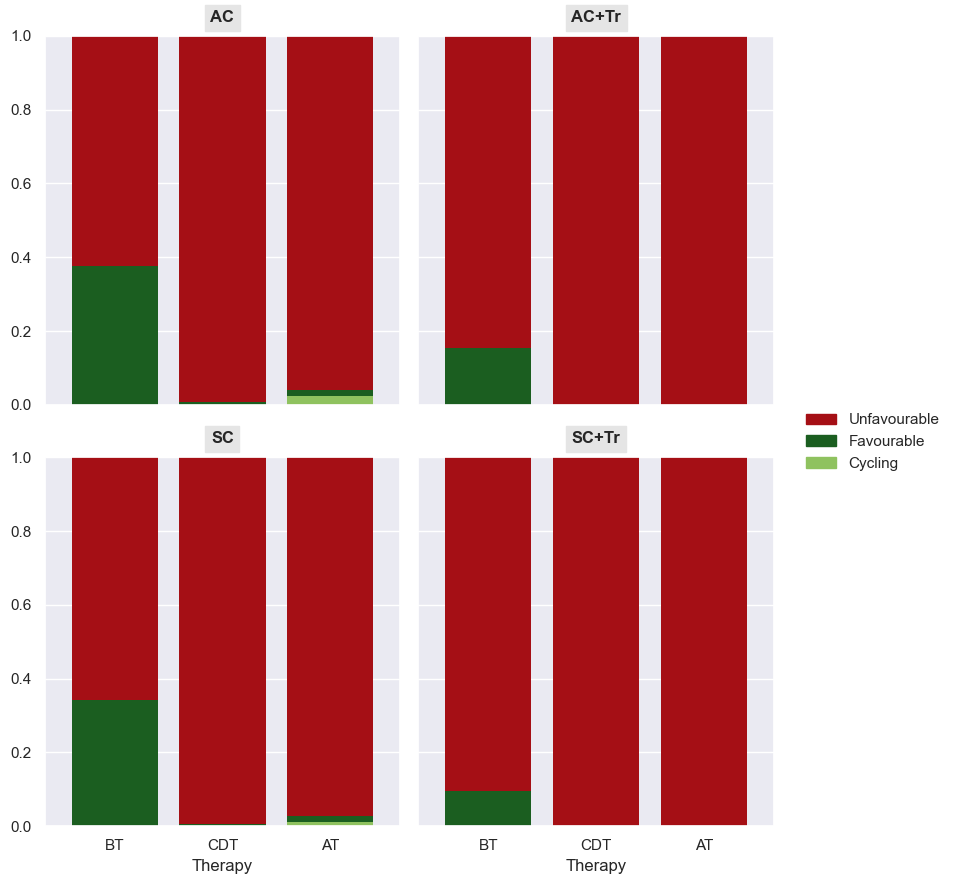

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files_da_leggere = ["virtual-cohort-cytotoxic-0.05-r1.csv", "virtual-cohort-cytotoxic-0.05-r2.csv", "virtual-cohort-cytotoxic-0.05-r3.csv"]
dati_raccolti = []
for nome_file in files_da_leggere:
    try:
        df = pd.read_csv(nome_file)
        dati_raccolti.append(df)
    except FileNotFoundError:
        print(f"File non trovato: {nome_file}")
        
df_tot = pd.concat(dati_raccolti, ignore_index=True) if dati_raccolti else pd.DataFrame()

RES_THRESHOLD = 0.15 
is_sym = np.isclose(df_tot['c'], df_tot['d'], atol=1e-4)
has_tr = (df_tot['a'] > 1e-6) | (df_tot['b'] > 1e-6)

df_tot['Modello'] = 'Unknown'
df_tot.loc[~is_sym & ~has_tr, 'Modello'] = 'AC'
df_tot.loc[~is_sym & has_tr, 'Modello'] = 'AC+Tr'
df_tot.loc[is_sym & ~has_tr, 'Modello'] = 'SC'
df_tot.loc[is_sym & has_tr, 'Modello'] = 'SC+Tr'

#BT
df_tot['Outcome_BT'] = np.where(df_tot['ResFracBT'] < RES_THRESHOLD, 'Favourable', 'Unfavourable')

#CDT
df_tot['Outcome_CDT'] = np.where(df_tot['ResFracCDT'] < RES_THRESHOLD, 'Favourable', 'Unfavourable')

#AT
df_tot['PeriodAT'] = pd.to_numeric(df_tot['PeriodAT'], errors='coerce')
is_cycling = (~np.isinf(df_tot['PeriodAT'])) & (df_tot['PeriodAT'].notna()) & (df_tot['PeriodAT'] > 0)

condizioni_at = [
    is_cycling,
    (~is_cycling) & (df_tot['ResFracAT'] < RES_THRESHOLD)
]

scelte_at = ['Cycling', 'Favourable']
df_tot['Outcome_AT'] = np.select(condizioni_at, scelte_at, default='Unfavourable')

df_plot = pd.melt(
    df_tot, 
    id_vars=['Modello'],
    value_vars=['Outcome_BT', 'Outcome_CDT', 'Outcome_AT'],
    var_name='Therapy', 
    value_name='Outcome'
)
df_plot['Therapy'] = df_plot['Therapy'].replace({'Outcome_BT': 'BT', 'Outcome_CDT': 'CDT', 'Outcome_AT': 'AT'})

prop_df = df_plot.groupby(['Modello', 'Therapy', 'Outcome']).size().unstack(fill_value=0)
prop_df = prop_df.div(prop_df.sum(axis=1), axis=0).reset_index()

colori = {'Unfavourable': '#a50f15', 'Favourable': '#1b5e20', 'Cycling': '#8fc25f'}

fig, axes = plt.subplots(2, 2, figsize=(8, 9), sharex=True, sharey=True)
axes = axes.flatten()
modelli = ['AC', 'AC+Tr', 'SC', 'SC+Tr']

for i, modello in enumerate(modelli):
    ax = axes[i]
    data = prop_df[prop_df['Modello'] == modello].set_index('Therapy').reindex(['BT', 'CDT', 'AT'])

    data[['Cycling', 'Favourable', 'Unfavourable']].plot(
        kind='bar', stacked=True, ax=ax, 
        color=[colori['Cycling'], colori['Favourable'], colori['Unfavourable']], 
        width=0.8, edgecolor='white', linewidth=0
    )
    
    ax.set_title(modello, backgroundcolor='#E5E5E5', pad=10, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.legend().remove()
    if i >= 2: ax.tick_params(axis='x', rotation=0)

handles = [plt.Rectangle((0,0),1,1, color=colori[l]) for l in ['Unfavourable', 'Favourable', 'Cycling']]
fig.legend(handles, ['Unfavourable', 'Favourable', 'Cycling'], loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

plt.tight_layout()
plt.savefig('FIG5A.png', dpi=300, bbox_inches='tight')
plt.show()

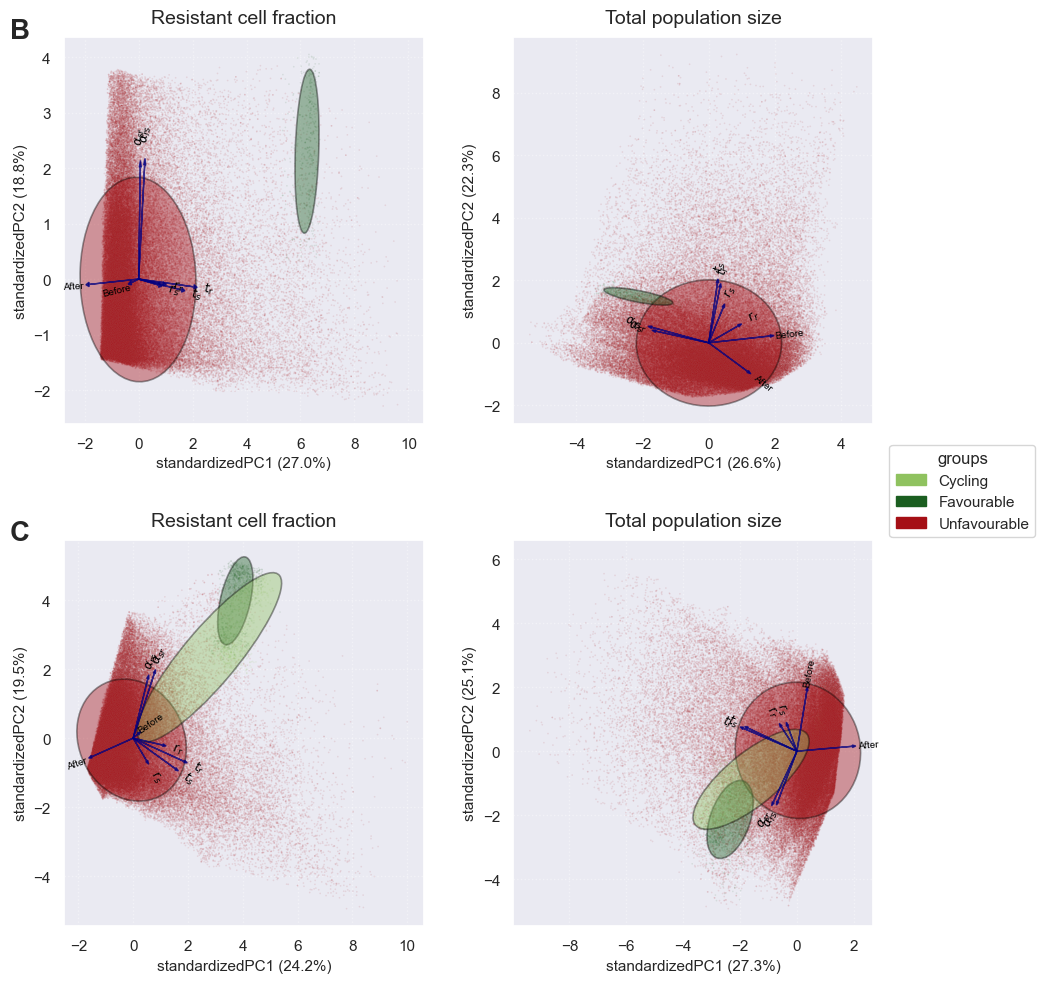

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse

RES_THRESHOLD = 0.15 
df_tot['Outcome_CDT'] = np.where(df_tot['ResFracCDT'] < RES_THRESHOLD, 'Favourable', 'Unfavourable')
df_tot['PeriodAT'] = pd.to_numeric(df_tot['PeriodAT'], errors='coerce')
is_cycling = (~np.isinf(df_tot['PeriodAT'])) & (df_tot['PeriodAT'].notna()) & (df_tot['PeriodAT'] > 0)
condizioni_at = [is_cycling, (~is_cycling) & (df_tot['ResFracAT'] < RES_THRESHOLD)]
df_tot['Outcome_AT'] = np.select(condizioni_at, ['Cycling', 'Favourable'], default='Unfavourable')
cols_to_check = ['a', 'b', 'c', 'd', 'r_x', 'r_y', 'ResFracBT', 'PopSizeBT', 'ResFracCDT', 'PopSizeCDT', 'ResFracAT', 'PopSizeAT']
df_pca = df_tot.dropna(subset=cols_to_check).copy()

colors_pca = {'Unfavourable': '#a50f15', 'Favourable': '#1b5e20', 'Cycling': '#8fc25f'}

param_labels = {
    'r_x': r'$r_s$', 'r_y': r'$r_r$', 
    'c': r'$\alpha_{rs}$', 'd': r'$\alpha_{sr}$', 
    'a': r'$t_s$', 'b': r'$t_r$',
    'Before': 'Before', 'After': 'After'
}

def draw_confidence_ellipse(ax, X_pca, outcome_series, target_outcome, color):
    group_data = X_pca[outcome_series == target_outcome]
    
    mean = np.mean(group_data, axis=0)
    cov = np.cov(group_data, rowvar=False)
    
    #Autovalori e autovettori per determinare dimensioni e rotazione
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    #2.279 è il valore critico del chi-quadro (df=2) per una confidenza del 68.27%. 
    #Dovrebbe essere il valore usata dalle funzioni di R che penso abbiano usato gli autori
    width = 2 * np.sqrt(2.279 * eigenvalues[0])
    height = 2 * np.sqrt(2.279 * eigenvalues[1])
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, 
                      edgecolor='black', facecolor=color, alpha=0.4, linewidth=1.2, zorder=2)
    ax.add_patch(ellipse)

def make_biplot(ax, df, outcome_col, feature_cols, title, before_col, after_col):
    X = df[feature_cols]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    var_1, var_2 = pca.explained_variance_ratio_ * 100
    
    outcomes_present = df[outcome_col].unique()
    palette = [colors_pca[o] for o in outcomes_present]
    
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df[outcome_col], 
                    palette=palette, s=1.5, alpha=0.10, ax=ax, zorder=1, legend=False)
    
    for outcome_name in outcomes_present:
        draw_confidence_ellipse(ax, X_pca, df[outcome_col], outcome_name, colors_pca[outcome_name])
        
    vector_weights = pca.components_.T * np.sqrt(pca.explained_variance_)
    scale_factor = 2.5
    
    logical_names = ['a', 'b', 'c', 'd', 'r_x', 'r_y', 'Before', 'After']
    
    for i, name in enumerate(logical_names):
        end_x = vector_weights[i, 0] * scale_factor
        end_y = vector_weights[i, 1] * scale_factor
        
        ax.arrow(0, 0, end_x, end_y, color='#000080', alpha=0.75, 
                 head_width=0.08, head_length=0.12, lw=1.0, length_includes_head=True, zorder=3)

        label = param_labels[name]
        
        angle_rad = np.arctan2(end_y, end_x)
        angle_deg = np.degrees(angle_rad)
        
        if angle_deg > 90:
            text_angle = angle_deg - 180
        elif angle_deg < -90:
            text_angle = angle_deg + 180
        else:
            text_angle = angle_deg

        offset_dist = 0.45 
        text_x = end_x + (np.cos(angle_rad) * offset_dist)
        text_y = end_y + (np.sin(angle_rad) * offset_dist)
        
        font_size = 7 if name in ['Before', 'After'] else 9
        
        ax.text(text_x, text_y, label, color='black', 
                ha='center', va='center', fontsize=font_size, fontweight='normal', 
                rotation=text_angle, rotation_mode='anchor', zorder=4)
        
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel(f"standardizedPC1 ({var_1:.1f}%)", fontsize=11)
    ax.set_ylabel(f"standardizedPC2 ({var_2:.1f}%)", fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.4)


fig, axes = plt.subplots(2, 2, figsize=(10, 10))

cols_b_res = ['a', 'b', 'c', 'd', 'r_x', 'r_y', 'ResFracBT', 'ResFracCDT']
cols_b_pop = ['a', 'b', 'c', 'd', 'r_x', 'r_y', 'PopSizeBT', 'PopSizeCDT']

cols_c_res = ['a', 'b', 'c', 'd', 'r_x', 'r_y', 'ResFracBT', 'ResFracAT']
cols_c_pop = ['a', 'b', 'c', 'd', 'r_x', 'r_y', 'PopSizeBT', 'PopSizeAT']

#CDT
make_biplot(axes[0, 0], df_pca, 'Outcome_CDT', cols_b_res, "Resistant cell fraction", 'ResFracBT', 'ResFracCDT')
make_biplot(axes[0, 1], df_pca, 'Outcome_CDT', cols_b_pop, "Total population size", 'PopSizeBT', 'PopSizeCDT')

#AT
make_biplot(axes[1, 0], df_pca, 'Outcome_AT', cols_c_res, "Resistant cell fraction", 'ResFracBT', 'ResFracAT')
make_biplot(axes[1, 1], df_pca, 'Outcome_AT', cols_c_pop, "Total population size", 'PopSizeBT', 'PopSizeAT')

axes[0, 0].text(-0.15, 1.05, "B", transform=axes[0, 0].transAxes, fontsize=20, fontweight='bold', va='top')
axes[1, 0].text(-0.15, 1.05, "C", transform=axes[1, 0].transAxes, fontsize=20, fontweight='bold', va='top')

handles = [plt.Rectangle((0,0),1,1, color=colors_pca[k]) for k in ['Cycling', 'Favourable', 'Unfavourable']]
fig.legend(handles, ['Cycling', 'Favourable', 'Unfavourable'], loc='center right', 
           bbox_to_anchor=(1.05, 0.5), title='groups', frameon=True, facecolor='white')

plt.tight_layout()
plt.subplots_adjust(right=0.88, wspace=0.25, hspace=0.3)
plt.savefig('FIG5B.png', dpi=300, bbox_inches='tight')
plt.show()

## Commenti:
I grafici della PCA sembrano gli stessi del paper ma con direzioni diverse. Anche le ellissi sembrano diverse. Probabilmente queste incongruenze sono dovute al fatto che gli autori hanno utilizzato R per plottare questi grafici, un altro linguaggio di programmazione che utilizza statistiche e geometrie diverse. Tuttavia, i grafici si leggono allo stesso modo e i risultati ottenuti sono gli stessi.